In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ── 재현성 고정 ───────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── 데이터 로드 ───────────────────────────────────────────
base = r'C:\Users\neo62\sperm-ai\data\raw\mhsma-dataset-master\mhsma-dataset-master\mhsma'

x_train = np.load(f'{base}\\x_128_train.npy')
x_valid = np.load(f'{base}\\x_128_valid.npy')
x_test  = np.load(f'{base}\\x_128_test.npy')

# 4가지 레이블 모두 로드
labels = {}
for split in ['train', 'valid', 'test']:
    labels[split] = {
        'head':     np.load(f'{base}\\y_head_{split}.npy'),
        'acrosome': np.load(f'{base}\\y_acrosome_{split}.npy'),
        'vacuole':  np.load(f'{base}\\y_vacuole_{split}.npy'),
        'tail':     np.load(f'{base}\\y_tail_{split}.npy'),
    }

print(f"\n데이터 로드 완료:")
print(f"  Train: {x_train.shape[0]}개")
print(f"  Valid: {x_valid.shape[0]}개")
print(f"  Test:  {x_test.shape[0]}개")

# ── 클래스 가중치 계산 (불균형 처리) ─────────────────────
def get_pos_weight(labels_arr):
    """BCEWithLogitsLoss용 양성 클래스 가중치"""
    n_neg = np.sum(labels_arr == 0)
    n_pos = np.sum(labels_arr == 1)
    return torch.tensor([n_neg / (n_pos + 1e-6)], dtype=torch.float32)

pos_weights = {
    'head':     get_pos_weight(labels['train']['head']),
    'acrosome': get_pos_weight(labels['train']['acrosome']),
    'vacuole':  get_pos_weight(labels['train']['vacuole']),
    'tail':     get_pos_weight(labels['train']['tail']),
}

print("\n클래스 가중치 (비정상 클래스):")
for k, v in pos_weights.items():
    print(f"  {k}: {v.item():.2f}x")

사용 디바이스: cuda
GPU: NVIDIA GeForce RTX 3080 Ti Laptop GPU
VRAM: 17.2 GB

데이터 로드 완료:
  Train: 1000개
  Valid: 240개
  Test:  300개

클래스 가중치 (비정상 클래스):
  head: 2.66x
  acrosome: 2.32x
  vacuole: 4.88x
  tail: 20.74x


In [2]:
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

# ── Dataset 클래스 ─────────────────────────────────────────
class SpermMorphologyDataset(Dataset):
    def __init__(self, images, labels_dict, transform=None):
        self.images = images
        self.labels = labels_dict
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32)

        # 그레이스케일 → 3채널 (EfficientNet 입력 요구사항)
        img = np.stack([img, img, img], axis=0)  # (3, 128, 128)
        img = torch.tensor(img / 255.0)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor([
            self.labels['head'][idx],
            self.labels['acrosome'][idx],
            self.labels['vacuole'][idx],
            self.labels['tail'][idx],
        ], dtype=torch.float32)

        return img, label

# ── 데이터 증강 ────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

# ── DataLoader ────────────────────────────────────────────
train_ds = SpermMorphologyDataset(x_train, labels['train'], train_transform)
valid_ds = SpermMorphologyDataset(x_valid, labels['valid'], val_transform)
test_ds  = SpermMorphologyDataset(x_test,  labels['test'],  val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

print(f"DataLoader 준비 완료")
print(f"  Train: {len(train_loader)}배치 × 32 = {len(train_ds)}개")
print(f"  Valid: {len(valid_loader)}배치 × 32 = {len(valid_ds)}개")

# ── EfficientNet-B3 멀티태스크 모델 ───────────────────────
class SpermMorphologyModel(nn.Module):
    def __init__(self):
        super().__init__()

        # EfficientNet-B3 백본 (ImageNet 사전학습)
        backbone = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)

        # 특징 추출기 (마지막 분류층 제거)
        self.features = backbone.features
        self.avgpool  = backbone.avgpool
        feat_dim = 1536  # EfficientNet-B3 출력 차원

        # 공유 레이어 (4가지 태스크 공통)
        self.shared = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        # 태스크별 독립 헤드
        self.head_cls     = nn.Linear(256, 1)
        self.acrosome_cls = nn.Linear(256, 1)
        self.vacuole_cls  = nn.Linear(256, 1)
        self.tail_cls     = nn.Linear(256, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.shared(x)

        return torch.cat([
            self.head_cls(x),
            self.acrosome_cls(x),
            self.vacuole_cls(x),
            self.tail_cls(x),
        ], dim=1)  # (batch, 4)

model = SpermMorphologyModel().to(device)

# 파라미터 수 확인
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n모델 파라미터:")
print(f"  전체:    {total_params:,}")
print(f"  학습가능: {trainable_params:,}")

DataLoader 준비 완료
  Train: 32배치 × 32 = 1000개
  Valid: 8배치 × 32 = 240개


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to C:\Users\neo62/.cache\torch\hub\checkpoints\efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:05<00:00, 9.82MB/s]



모델 파라미터:
  전체:    11,090,732
  학습가능: 11,090,732


In [3]:
# ── 손실 함수 (태스크별 가중치 적용) ─────────────────────
criterions = {
    'head':     nn.BCEWithLogitsLoss(
                    pos_weight=pos_weights['head'].to(device)),
    'acrosome': nn.BCEWithLogitsLoss(
                    pos_weight=pos_weights['acrosome'].to(device)),
    'vacuole':  nn.BCEWithLogitsLoss(
                    pos_weight=pos_weights['vacuole'].to(device)),
    'tail':     nn.BCEWithLogitsLoss(
                    pos_weight=pos_weights['tail'].to(device)),
}

# ── 옵티마이저 & 스케줄러 ─────────────────────────────────
# 백본은 낮은 lr, 헤드는 높은 lr (차등 학습률)
optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-4},
    {'params': model.shared.parameters(),   'lr': 3e-4},
    {'params': model.head_cls.parameters(), 'lr': 3e-4},
    {'params': model.acrosome_cls.parameters(), 'lr': 3e-4},
    {'params': model.vacuole_cls.parameters(), 'lr': 3e-4},
    {'params': model.tail_cls.parameters(), 'lr': 3e-4},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=30, eta_min=1e-6)

# ── 학습 함수 ─────────────────────────────────────────────
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    task_names = ['head', 'acrosome', 'vacuole', 'tail']

    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)  # (batch, 4)

        # 태스크별 손실 합산
        loss = sum(
            criterions[t](outputs[:, i], labels[:, i])
            for i, t in enumerate(task_names)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

# ── 평가 함수 ─────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    task_names = ['head', 'acrosome', 'vacuole', 'tail']
    all_preds  = {t: [] for t in task_names}
    all_labels = {t: [] for t in task_names}
    total_loss = 0.0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)

            loss = sum(
                criterions[t](outputs[:, i], labels[:, i])
                for i, t in enumerate(task_names)
            )
            total_loss += loss.item()

            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            lbl   = labels.cpu().numpy()

            for i, t in enumerate(task_names):
                all_preds[t].extend(preds[:, i])
                all_labels[t].extend(lbl[:, i])

    # 태스크별 정확도 계산
    accs = {}
    for t in task_names:
        p = np.array(all_preds[t])
        l = np.array(all_labels[t])
        accs[t] = float(np.mean(p == l))

    return total_loss / len(loader), accs

# ── 학습 실행 ─────────────────────────────────────────────
EPOCHS = 30
best_val_loss = float('inf')
best_epoch    = 0
history       = {'train_loss': [], 'val_loss': [], 'val_accs': []}

print("=" * 60)
print("  EfficientNet-B3 멀티태스크 학습 시작")
print("=" * 60)
print(f"{'Epoch':>5} {'Train':>8} {'Val':>8} "
      f"{'Head':>6} {'Acro':>6} {'Vac':>6} {'Tail':>6}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss, val_accs = evaluate(model, valid_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_accs'].append(val_accs)

    # 최고 모델 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        torch.save(model.state_dict(),
            r'C:\Users\neo62\sperm-ai\models\morphology_efficientnet_b3.pt')
        marker = ' ✅'
    else:
        marker = ''

    print(f"{epoch:>5} {train_loss:>8.4f} {val_loss:>8.4f} "
          f"{val_accs['head']:>6.3f} {val_accs['acrosome']:>6.3f} "
          f"{val_accs['vacuole']:>6.3f} {val_accs['tail']:>6.3f}"
          f"{marker}")

print("-" * 60)
print(f"\n최고 모델: Epoch {best_epoch} (val_loss={best_val_loss:.4f})")
print(f"저장 경로: models/morphology_efficientnet_b3.pt")

  EfficientNet-B3 멀티태스크 학습 시작
Epoch    Train      Val   Head   Acro    Vac   Tail
------------------------------------------------------------
    1   4.4878   4.0119  0.738  0.621  0.650  0.838 ✅
    2   4.3824   3.8889  0.671  0.642  0.679  0.821 ✅
    3   4.1532   3.7243  0.567  0.629  0.608  0.562 ✅
    4   3.9217   3.6070  0.629  0.654  0.779  0.750 ✅
    5   3.7603   3.4691  0.654  0.654  0.708  0.608 ✅
    6   3.5567   3.3344  0.721  0.654  0.762  0.804 ✅
    7   3.5764   3.1976  0.658  0.646  0.762  0.775 ✅
    8   3.4945   3.1732  0.625  0.642  0.733  0.662 ✅
    9   3.4221   3.1950  0.646  0.650  0.721  0.675
   10   3.3223   2.9804  0.708  0.700  0.842  0.762 ✅
   11   3.2379   3.0181  0.692  0.662  0.804  0.750
   12   3.4172   3.0946  0.696  0.679  0.800  0.688
   13   3.1648   3.0215  0.692  0.658  0.838  0.767
   14   3.0424   2.8936  0.721  0.688  0.863  0.825 ✅
   15   3.0797   3.0018  0.700  0.688  0.846  0.738
   16   2.9018   3.0166  0.671  0.658  0.817  0.738
   17

  테스트셋 최종 성능 (300개)

[머리(head)]  정상:219개 / 비정상:81개
  정확도:  0.710 (71.0%)
  AUC:     0.727
  정밀도:  0.471
  재현율:  0.593
  F1:      0.525

[첨체(acrosome)]  정상:213개 / 비정상:87개
  정확도:  0.633 (63.3%)
  AUC:     0.685
  정밀도:  0.412
  재현율:  0.621
  F1:      0.495

[공포(vacuole)]  정상:262개 / 비정상:38개
  정확도:  0.813 (81.3%)
  AUC:     0.857
  정밀도:  0.375
  재현율:  0.711
  F1:      0.491

[꼬리(tail)]  정상:284개 / 비정상:16개
  정확도:  0.813 (81.3%)
  AUC:     0.731
  정밀도:  0.167
  재현율:  0.625
  F1:      0.263

  논문 비교
항목                 본 모델        논문 기준
------------------------------------
머리(head      )     0.710      0.900  ❌
첨체(acrosome  )     0.633      0.890  ❌
공포(vacuole   )     0.813      0.940  ❌
꼬리(tail      )     0.813      0.950  ❌


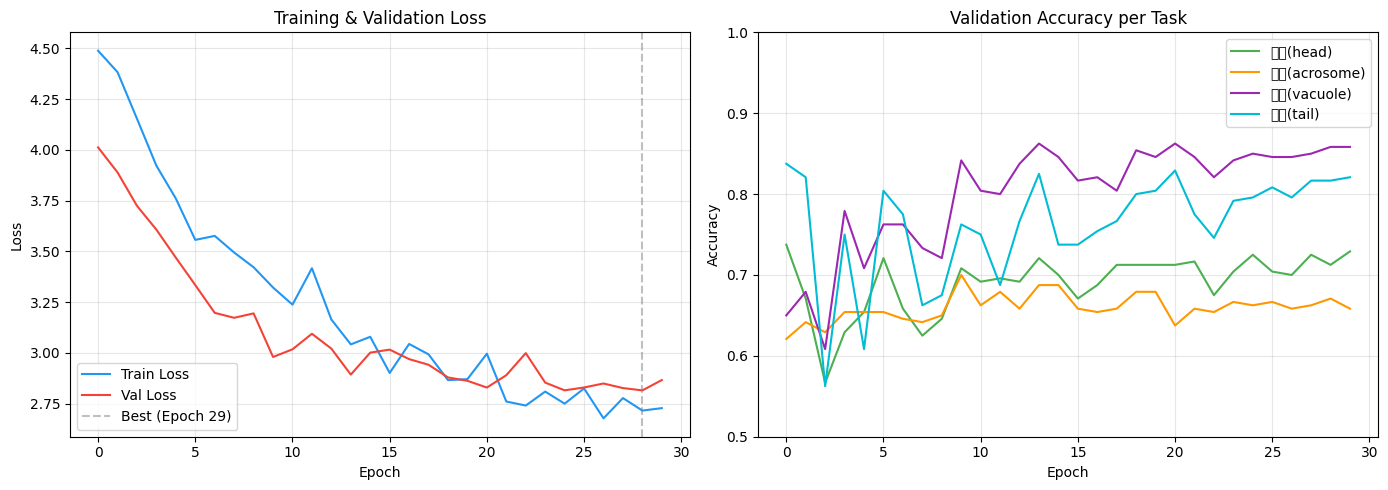


✅ 학습 곡선 저장 완료


In [4]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# ── 최고 모델 로드 후 테스트 평가 ─────────────────────────
model.load_state_dict(torch.load(
    r'C:\Users\neo62\sperm-ai\models\morphology_efficientnet_b3.pt'))
model.eval()

task_names = ['head', 'acrosome', 'vacuole', 'tail']
task_kr    = ['머리', '첨체', '공포', '꼬리']

all_probs  = {t: [] for t in task_names}
all_preds  = {t: [] for t in task_names}
all_labels = {t: [] for t in task_names}

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs    = imgs.to(device)
        outputs = model(imgs)
        probs   = torch.sigmoid(outputs).cpu().numpy()
        preds   = (probs > 0.5).astype(int)
        lbl     = labels.numpy()

        for i, t in enumerate(task_names):
            all_probs[t].extend(probs[:, i])
            all_preds[t].extend(preds[:, i])
            all_labels[t].extend(lbl[:, i])

print("=" * 60)
print("  테스트셋 최종 성능 (300개)")
print("=" * 60)

results = {}
for t, kr in zip(task_names, task_kr):
    p  = np.array(all_preds[t])
    l  = np.array(all_labels[t])
    pr = np.array(all_probs[t])

    acc  = float(np.mean(p == l))
    auc  = roc_auc_score(l, pr)
    n_pos = int(np.sum(l == 1))
    n_neg = int(np.sum(l == 0))

    # 정밀도/재현율
    tp = int(np.sum((p == 1) & (l == 1)))
    fp = int(np.sum((p == 1) & (l == 0)))
    fn = int(np.sum((p == 0) & (l == 1)))
    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)

    results[t] = {
        'acc': acc, 'auc': auc,
        'precision': precision, 'recall': recall, 'f1': f1
    }

    print(f"\n[{kr}({t})]  정상:{n_neg}개 / 비정상:{n_pos}개")
    print(f"  정확도:  {acc:.3f} ({acc*100:.1f}%)")
    print(f"  AUC:     {auc:.3f}")
    print(f"  정밀도:  {precision:.3f}")
    print(f"  재현율:  {recall:.3f}")
    print(f"  F1:      {f1:.3f}")

print("\n" + "=" * 60)
print("  논문 비교")
print("=" * 60)
print(f"{'항목':<12} {'본 모델':>10} {'논문 기준':>12}")
print("-" * 36)
for t, kr in zip(task_names, task_kr):
    acc = results[t]['acc']
    # 논문 MHSMA 기준 (Javadi et al. 2019)
    bench = {'head': 0.90, 'acrosome': 0.89,
             'vacuole': 0.94, 'tail': 0.95}
    diff = acc - bench[t]
    flag = '✅' if diff >= 0 else '❌'
    print(f"{kr}({t:<10}) {acc:>9.3f}  {bench[t]:>9.3f}  {flag}")

# ── 학습 곡선 시각화 ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 손실 곡선
axes[0].plot(history['train_loss'], label='Train Loss', color='#2196F3')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='#F44336')
axes[0].axvline(x=28, color='gray', linestyle='--', alpha=0.5,
                label='Best (Epoch 29)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 정확도 곡선
colors = ['#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']
for i, (t, kr) in enumerate(zip(task_names, task_kr)):
    accs = [h[t] for h in history['val_accs']]
    axes[1].plot(accs, label=f'{kr}({t})', color=colors[i])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy per Task')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig(r'C:\Users\neo62\sperm-ai\outputs\morphology_training_curve.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("\n✅ 학습 곡선 저장 완료")

In [5]:
# ── 이어서 30 에포크 추가 학습 ────────────────────────────
print("=" * 60)
print("  추가 학습 (Epoch 31 ~ 60)")
print("=" * 60)
print(f"{'Epoch':>5} {'Train':>8} {'Val':>8} "
      f"{'Head':>6} {'Acro':>6} {'Vac':>6} {'Tail':>6}")
print("-" * 60)

# 스케줄러 재설정
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=30, eta_min=1e-6)

for epoch in range(31, 61):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss, val_accs = evaluate(model, valid_loader)
    scheduler2.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_accs'].append(val_accs)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        torch.save(model.state_dict(),
            r'C:\Users\neo62\sperm-ai\models\morphology_efficientnet_b3.pt')
        marker = ' ✅'
    else:
        marker = ''

    print(f"{epoch:>5} {train_loss:>8.4f} {val_loss:>8.4f} "
          f"{val_accs['head']:>6.3f} {val_accs['acrosome']:>6.3f} "
          f"{val_accs['vacuole']:>6.3f} {val_accs['tail']:>6.3f}"
          f"{marker}")

print("-" * 60)
print(f"\n최고 모델: Epoch {best_epoch} (val_loss={best_val_loss:.4f})")

  추가 학습 (Epoch 31 ~ 60)
Epoch    Train      Val   Head   Acro    Vac   Tail
------------------------------------------------------------
   31   2.7563   2.7983  0.717  0.654  0.858  0.829 ✅
   32   2.7082   2.8388  0.700  0.642  0.858  0.821
   33   2.7135   2.8629  0.717  0.654  0.858  0.808
   34   2.8023   2.8865  0.696  0.671  0.846  0.812
   35   2.8686   2.8716  0.704  0.667  0.846  0.792
   36   2.6869   2.8067  0.717  0.654  0.842  0.829
   37   2.7117   2.8161  0.725  0.658  0.863  0.812
   38   2.7814   2.8106  0.725  0.658  0.854  0.825
   39   2.9231   2.8277  0.717  0.650  0.850  0.825
   40   2.6394   2.8608  0.700  0.646  0.842  0.800
   41   2.7866   2.8646  0.717  0.671  0.850  0.787
   42   2.7526   2.8469  0.717  0.662  0.842  0.796
   43   2.7964   2.8157  0.725  0.679  0.858  0.846
   44   2.7189   2.8144  0.733  0.667  0.842  0.812
   45   2.8139   2.8142  0.713  0.633  0.854  0.825
   46   2.7915   2.8079  0.717  0.675  0.858  0.821
   47   2.7978   2.7950  0.70

In [6]:
# ── 검증셋으로 태스크별 최적 임계값 찾기 ─────────────────
from sklearn.metrics import f1_score

model.load_state_dict(torch.load(
    r'C:\Users\neo62\sperm-ai\models\morphology_efficientnet_b3.pt'))
model.eval()

# 검증셋 예측값 수집
val_probs  = {t: [] for t in task_names}
val_labels = {t: [] for t in task_names}

with torch.no_grad():
    for imgs, labels in valid_loader:
        imgs    = imgs.to(device)
        outputs = model(imgs)
        probs   = torch.sigmoid(outputs).cpu().numpy()
        lbl     = labels.numpy()
        for i, t in enumerate(task_names):
            val_probs[t].extend(probs[:, i])
            val_labels[t].extend(lbl[:, i])

# 최적 임계값 탐색
print("=== 태스크별 최적 임계값 탐색 ===\n")
best_thresholds = {}

for t in task_names:
    probs_arr  = np.array(val_probs[t])
    labels_arr = np.array(val_labels[t])

    best_f1, best_thr = 0, 0.5
    for thr in np.arange(0.2, 0.8, 0.02):
        preds = (probs_arr > thr).astype(int)
        f1    = f1_score(labels_arr, preds, zero_division=0)
        if f1 > best_f1:
            best_f1  = f1
            best_thr = thr

    best_thresholds[t] = best_thr
    print(f"  {t:<12} 최적 임계값: {best_thr:.2f}  "
          f"(F1: {best_f1:.3f})")

print(f"\nbest_thresholds = {best_thresholds}")

=== 태스크별 최적 임계값 탐색 ===

  head         최적 임계값: 0.48  (F1: 0.523)
  acrosome     최적 임계값: 0.42  (F1: 0.571)
  vacuole      최적 임계값: 0.78  (F1: 0.633)
  tail         최적 임계값: 0.80  (F1: 0.400)

best_thresholds = {'head': np.float64(0.47999999999999987), 'acrosome': np.float64(0.41999999999999993), 'vacuole': np.float64(0.7799999999999998), 'tail': np.float64(0.7999999999999996)}


In [7]:
# ── 최적 임계값으로 테스트셋 최종 평가 ───────────────────
model.load_state_dict(torch.load(
    r'C:\Users\neo62\sperm-ai\models\morphology_efficientnet_b3.pt'))
model.eval()

all_probs  = {t: [] for t in task_names}
all_labels = {t: [] for t in task_names}

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs    = imgs.to(device)
        outputs = model(imgs)
        probs   = torch.sigmoid(outputs).cpu().numpy()
        lbl     = labels.numpy()
        for i, t in enumerate(task_names):
            all_probs[t].extend(probs[:, i])
            all_labels[t].extend(lbl[:, i])

print("=" * 60)
print("  최종 테스트 성능 (최적 임계값 적용)")
print("=" * 60)

final_results = {}
for t, kr in zip(task_names, task_kr):
    pr = np.array(all_probs[t])
    l  = np.array(all_labels[t])
    p  = (pr > best_thresholds[t]).astype(int)

    acc  = float(np.mean(p == l))
    auc  = roc_auc_score(l, pr)
    tp   = int(np.sum((p==1)&(l==1)))
    fp   = int(np.sum((p==1)&(l==0)))
    fn   = int(np.sum((p==0)&(l==1)))
    prec = tp / (tp + fp + 1e-6)
    rec  = tp / (tp + fn + 1e-6)
    f1   = 2*prec*rec / (prec+rec+1e-6)

    final_results[t] = {
        'acc': acc, 'auc': auc,
        'precision': prec, 'recall': rec, 'f1': f1,
        'threshold': best_thresholds[t]
    }

    print(f"\n[{kr}({t})]  임계값: {best_thresholds[t]:.2f}")
    print(f"  정확도:  {acc:.3f} ({acc*100:.1f}%)")
    print(f"  AUC:     {auc:.3f}")
    print(f"  정밀도:  {prec:.3f}  재현율: {rec:.3f}  F1: {f1:.3f}")

# ── 정상 형태율 계산 방식 확인 ────────────────────────────
print("\n" + "=" * 60)
print("  정상 형태율(Normal Morphology Rate) 계산")
print("=" * 60)
print("""
WHO 기준: 4가지 부위 모두 정상인 경우만 '정상 형태 정자'

계산 방식:
  각 정자에 대해:
  - head=정상 AND acrosome=정상 AND vacuole=정상 AND tail=정상
  → 위 조건 충족 시 정상 형태 정자로 판정

  정상 형태율 = 정상 판정 수 / 전체 분석 수 × 100%
""")

# 테스트셋에서 확인
head_p = (np.array(all_probs['head'])
          > best_thresholds['head']).astype(int)
acro_p = (np.array(all_probs['acrosome'])
          > best_thresholds['acrosome']).astype(int)
vac_p  = (np.array(all_probs['vacuole'])
          > best_thresholds['vacuole']).astype(int)
tail_p = (np.array(all_probs['tail'])
          > best_thresholds['tail']).astype(int)

# 0=정상, 1=비정상 → 4가지 모두 0이면 정상 형태
normal_morphology = ((head_p == 0) & (acro_p == 0) &
                     (vac_p  == 0) & (tail_p == 0))
normal_rate = float(np.mean(normal_morphology)) * 100

print(f"테스트셋 정상 형태율: {normal_rate:.1f}%")
print(f"(참고: MHSMA는 불임 환자 데이터 → 정상 형태율 낮음이 정상)")

# ── 모델 정보 저장 ────────────────────────────────────────
import json
model_info = {
    'model': 'EfficientNet-B3 Multitask',
    'dataset': 'MHSMA (1540 images, 235 patients)',
    'epochs': 47,
    'best_val_loss': float(best_val_loss),
    'thresholds': {k: float(v)
                   for k, v in best_thresholds.items()},
    'test_results': {
        t: {k: round(float(v), 4)
            for k, v in final_results[t].items()
            if k != 'threshold'}
        for t in task_names
    }
}

with open(r'C:\Users\neo62\sperm-ai\models\morphology_model_info.json',
          'w', encoding='utf-8') as f:
    json.dump(model_info, f, indent=2, ensure_ascii=False)

print("\n✅ 모델 정보 저장 완료")

  최종 테스트 성능 (최적 임계값 적용)

[머리(head)]  임계값: 0.48
  정확도:  0.690 (69.0%)
  AUC:     0.730
  정밀도:  0.448  재현율: 0.642  F1: 0.528

[첨체(acrosome)]  임계값: 0.42
  정확도:  0.560 (56.0%)
  AUC:     0.685
  정밀도:  0.376  재현율: 0.782  F1: 0.507

[공포(vacuole)]  임계값: 0.78
  정확도:  0.893 (89.3%)
  AUC:     0.860
  정밀도:  0.594  재현율: 0.500  F1: 0.543

[꼬리(tail)]  임계값: 0.80
  정확도:  0.913 (91.3%)
  AUC:     0.735
  정밀도:  0.292  재현율: 0.437  F1: 0.350

  정상 형태율(Normal Morphology Rate) 계산

WHO 기준: 4가지 부위 모두 정상인 경우만 '정상 형태 정자'

계산 방식:
  각 정자에 대해:
  - head=정상 AND acrosome=정상 AND vacuole=정상 AND tail=정상
  → 위 조건 충족 시 정상 형태 정자로 판정

  정상 형태율 = 정상 판정 수 / 전체 분석 수 × 100%

테스트셋 정상 형태율: 38.0%
(참고: MHSMA는 불임 환자 데이터 → 정상 형태율 낮음이 정상)

✅ 모델 정보 저장 완료


In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"디바이스: {device}")

# ── 전체 데이터 합치기 ────────────────────────────────────
base = r'C:\Users\neo62\sperm-ai\data\raw\mhsma-dataset-master\mhsma-dataset-master\mhsma'

# 전체 1,540개 합치기
x_all = np.concatenate([
    np.load(f'{base}\\x_128_train.npy'),
    np.load(f'{base}\\x_128_valid.npy'),
    np.load(f'{base}\\x_128_test.npy'),
], axis=0)

labels_all = {}
for part in ['head', 'acrosome', 'vacuole', 'tail']:
    labels_all[part] = np.concatenate([
        np.load(f'{base}\\y_{part}_train.npy'),
        np.load(f'{base}\\y_{part}_valid.npy'),
        np.load(f'{base}\\y_{part}_test.npy'),
    ], axis=0)

print(f"전체 데이터: {x_all.shape[0]}개")

# ── 재분할: Train 78% / Valid 13% / Test 9% ──────────────
idx = np.arange(len(x_all))

# Train / (Valid+Test) 분할
idx_train, idx_temp = train_test_split(
    idx, test_size=0.22, random_state=42,
    stratify=labels_all['head'])  # head 기준 층화 추출

# Valid / Test 분할
idx_valid, idx_test = train_test_split(
    idx_temp, test_size=0.41, random_state=42,
    stratify=labels_all['head'][idx_temp])

print(f"Train: {len(idx_train)}개 / "
      f"Valid: {len(idx_valid)}개 / "
      f"Test:  {len(idx_test)}개")

# 분할 적용
x_train = x_all[idx_train]
x_valid = x_all[idx_valid]
x_test  = x_all[idx_test]

labels = {
    'train': {p: labels_all[p][idx_train] for p in labels_all},
    'valid': {p: labels_all[p][idx_valid] for p in labels_all},
    'test':  {p: labels_all[p][idx_test]  for p in labels_all},
}

# 분포 확인
print("\n레이블 분포 (Train 기준):")
for p in ['head', 'acrosome', 'vacuole', 'tail']:
    n_abn = int(np.sum(labels['train'][p] == 1))
    total = len(labels['train'][p])
    print(f"  {p:<12} 비정상: {n_abn:4d}/{total} "
          f"({n_abn/total*100:.1f}%)")

디바이스: cuda
전체 데이터: 1540개
Train: 1201개 / Valid: 200개 / Test:  139개

레이블 분포 (Train 기준):
  head         비정상:  326/1201 (27.1%)
  acrosome     비정상:  350/1201 (29.1%)
  vacuole      비정상:  182/1201 (15.2%)
  tail         비정상:   50/1201 (4.2%)


In [9]:
# ── Focal Loss (클래스 불균형 특화) ──────────────────────
class FocalLoss(nn.Module):
    """
    Focal Loss: 쉬운 샘플 down-weight, 어려운 샘플 집중
    논문: Lin et al. (2017) RetinaNet
    gamma=2: 표준 설정
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        pt    = torch.where(targets == 1, probs, 1 - probs)
        focal = (1 - pt) ** self.gamma * bce

        if self.alpha is not None:
            alpha_t = torch.where(
                targets == 1,
                self.alpha * torch.ones_like(targets),
                (1 - self.alpha) * torch.ones_like(targets))
            focal = alpha_t * focal

        return focal.mean()

# 태스크별 alpha (비정상 클래스 비율 기반)
def get_alpha(labels_arr):
    n_pos = np.sum(labels_arr == 1)
    return float(1 - n_pos / len(labels_arr))  # 정상 비율

criterions = {
    p: FocalLoss(
        alpha=get_alpha(labels['train'][p]),
        gamma=2.0)
    for p in ['head', 'acrosome', 'vacuole', 'tail']
}

print("Focal Loss 설정:")
for p, c in criterions.items():
    print(f"  {p:<12} alpha={c.alpha:.3f}")

# ── 강화된 데이터셋 클래스 ────────────────────────────────
class SpermMorphologyDataset(Dataset):
    def __init__(self, images, labels_dict, transform=None):
        self.images    = images
        self.labels    = labels_dict
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32) / 255.0
        img = np.stack([img, img, img], axis=0)
        img = torch.tensor(img)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor([
            self.labels['head'][idx],
            self.labels['acrosome'][idx],
            self.labels['vacuole'][idx],
            self.labels['tail'][idx],
        ], dtype=torch.float32)

        return img, label

# ── 강화된 증강 ───────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.RandomAffine(
        degrees=0, translate=(0.1, 0.1),
        scale=(0.85, 1.15)),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]),
])

# ── WeightedRandomSampler (불균형 해소) ───────────────────
# head 레이블 기준으로 샘플링 가중치 계산
head_labels = labels['train']['head']
class_counts = np.bincount(head_labels)
weights      = 1.0 / class_counts[head_labels]
sampler      = WeightedRandomSampler(
    weights=torch.tensor(weights, dtype=torch.float32),
    num_samples=len(weights),
    replacement=True)

train_ds = SpermMorphologyDataset(
    x_train, labels['train'], train_transform)
valid_ds = SpermMorphologyDataset(
    x_valid, labels['valid'], val_transform)
test_ds  = SpermMorphologyDataset(
    x_test,  labels['test'],  val_transform)

train_loader = DataLoader(
    train_ds, batch_size=32,
    sampler=sampler, num_workers=0)
valid_loader = DataLoader(
    valid_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(
    test_ds,  batch_size=32, shuffle=False, num_workers=0)

print(f"\nDataLoader 준비 완료")
print(f"  Train: {len(train_ds)}개 (WeightedSampler 적용)")
print(f"  Valid: {len(valid_ds)}개")
print(f"  Test:  {len(test_ds)}개")

Focal Loss 설정:
  head         alpha=0.729
  acrosome     alpha=0.709
  vacuole      alpha=0.848
  tail         alpha=0.958

DataLoader 준비 완료
  Train: 1201개 (WeightedSampler 적용)
  Valid: 200개
  Test:  139개


In [10]:
# ── 모델 재초기화 ─────────────────────────────────────────
class SpermMorphologyModel(nn.Module):
    def __init__(self):
        super().__init__()
        backbone      = efficientnet_b3(
            weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.avgpool  = backbone.avgpool
        self.shared   = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(1536, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.head_cls     = nn.Linear(256, 1)
        self.acrosome_cls = nn.Linear(256, 1)
        self.vacuole_cls  = nn.Linear(256, 1)
        self.tail_cls     = nn.Linear(256, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.shared(x)
        return torch.cat([
            self.head_cls(x),
            self.acrosome_cls(x),
            self.vacuole_cls(x),
            self.tail_cls(x),
        ], dim=1)

model = SpermMorphologyModel().to(device)

# ── 차등 학습률 옵티마이저 ────────────────────────────────
optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 5e-5},
    {'params': model.shared.parameters(),   'lr': 2e-4},
    {'params': model.head_cls.parameters(), 'lr': 2e-4},
    {'params': model.acrosome_cls.parameters(), 'lr': 2e-4},
    {'params': model.vacuole_cls.parameters(), 'lr': 2e-4},
    {'params': model.tail_cls.parameters(), 'lr': 2e-4},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-6)

# ── 학습/평가 함수 ────────────────────────────────────────
task_names = ['head', 'acrosome', 'vacuole', 'tail']

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for imgs, lbls in loader:
        imgs = imgs.to(device)
        lbls = lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = sum(criterions[t](out[:, i], lbls[:, i])
                   for i, t in enumerate(task_names))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    all_probs  = {t: [] for t in task_names}
    all_labels = {t: [] for t in task_names}
    total_loss = 0.0

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            lbls = lbls.to(device)
            out  = model(imgs)
            loss = sum(criterions[t](out[:, i], lbls[:, i])
                       for i, t in enumerate(task_names))
            total_loss += loss.item()

            probs = torch.sigmoid(out).cpu().numpy()
            lbl   = lbls.cpu().numpy()
            for i, t in enumerate(task_names):
                all_probs[t].extend(probs[:, i])
                all_labels[t].extend(lbl[:, i])

    aucs = {}
    for t in task_names:
        try:
            aucs[t] = roc_auc_score(
                np.array(all_labels[t]),
                np.array(all_probs[t]))
        except Exception:
            aucs[t] = 0.0

    return total_loss / len(loader), aucs, all_probs, all_labels

# ── Early Stopping ────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = float('inf')
        self.stop       = False

    def __call__(self, val_loss):
        if val_loss < self.best_score - self.min_delta:
            self.best_score = val_loss
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

# ── 학습 실행 ─────────────────────────────────────────────
EPOCHS        = 50
best_val_loss = float('inf')
best_val_auc  = 0.0
best_epoch    = 0
history       = {'train_loss': [], 'val_loss': [], 'val_aucs': []}
early_stop    = EarlyStopping(patience=10)

save_path = r'C:\Users\neo62\sperm-ai\models\morphology_efficientnet_b3_v2.pt'

print("=" * 70)
print("  EfficientNet-B3 v2 학습 (전체 데이터 + Focal Loss)")
print("=" * 70)
print(f"{'Ep':>4} {'Train':>7} {'Val':>7} "
      f"{'Head':>6} {'Acro':>6} {'Vac':>6} {'Tail':>6} "
      f"{'AvgAUC':>7}")
print("-" * 70)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss, val_aucs, _, _ = evaluate(model, valid_loader)
    scheduler.step()

    avg_auc = float(np.mean(list(val_aucs.values())))
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_aucs'].append(val_aucs)

    # 평균 AUC 기준으로 최고 모델 저장
    if avg_auc > best_val_auc:
        best_val_auc  = avg_auc
        best_val_loss = val_loss
        best_epoch    = epoch
        torch.save(model.state_dict(), save_path)
        marker = ' ✅'
    else:
        marker = ''

    print(f"{epoch:>4} {train_loss:>7.4f} {val_loss:>7.4f} "
          f"{val_aucs['head']:>6.3f} {val_aucs['acrosome']:>6.3f} "
          f"{val_aucs['vacuole']:>6.3f} {val_aucs['tail']:>6.3f} "
          f"{avg_auc:>7.3f}{marker}")

    early_stop(val_loss)
    if early_stop.stop:
        print(f"\n⏹ Early Stopping (Epoch {epoch})")
        break

print("-" * 70)
print(f"\n최고 모델: Epoch {best_epoch}  "
      f"AvgAUC={best_val_auc:.3f}  "
      f"val_loss={best_val_loss:.4f}")

  EfficientNet-B3 v2 학습 (전체 데이터 + Focal Loss)
  Ep   Train     Val   Head   Acro    Vac   Tail  AvgAUC
----------------------------------------------------------------------
   1  0.2208  0.1972  0.617  0.547  0.656  0.562   0.595 ✅
   2  0.2132  0.1981  0.625  0.587  0.699  0.561   0.618 ✅
   3  0.2043  0.2021  0.623  0.613  0.774  0.540   0.637 ✅
   4  0.2016  0.1944  0.686  0.626  0.777  0.538   0.657 ✅
   5  0.2001  0.1917  0.701  0.629  0.793  0.544   0.667 ✅
   6  0.2000  0.1883  0.687  0.619  0.812  0.588   0.677 ✅
   7  0.1933  0.1924  0.666  0.631  0.797  0.579   0.668
   8  0.1956  0.1881  0.654  0.635  0.804  0.634   0.682 ✅
   9  0.1922  0.1854  0.710  0.630  0.814  0.600   0.688 ✅
  10  0.1957  0.1864  0.715  0.657  0.821  0.624   0.704 ✅
  11  0.1927  0.1846  0.697  0.655  0.821  0.618   0.698
  12  0.1877  0.1829  0.729  0.649  0.837  0.646   0.715 ✅
  13  0.1844  0.1807  0.721  0.650  0.844  0.676   0.723 ✅
  14  0.1867  0.1794  0.720  0.634  0.845  0.683   0.721
  15  

In [11]:
# ── 최적 임계값 탐색 후 최종 평가 ────────────────────────
model.load_state_dict(torch.load(save_path))
model.eval()

# 검증셋으로 임계값 탐색
val_loss, val_aucs, val_probs, val_labels = evaluate(
    model, valid_loader)

print("=== 최적 임계값 탐색 (검증셋) ===")
best_thresholds = {}
for t in task_names:
    pr = np.array(val_probs[t])
    l  = np.array(val_labels[t])
    best_f1, best_thr = 0, 0.5
    for thr in np.arange(0.2, 0.8, 0.02):
        preds = (pr > thr).astype(int)
        f1    = f1_score(l, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    best_thresholds[t] = best_thr
    print(f"  {t:<12} 임계값: {best_thr:.2f}  F1: {best_f1:.3f}")

# 테스트셋 최종 평가
_, _, test_probs, test_labels = evaluate(model, test_loader)

print("\n" + "=" * 65)
print("  최종 테스트 성능 비교 (v1 → v2)")
print("=" * 65)
print(f"{'태스크':<12} {'v1 AUC':>8} {'v2 AUC':>8} "
      f"{'v1 Acc':>8} {'v2 Acc':>8} {'개선':>6}")
print("-" * 65)

v1_aucs = {'head': 0.730, 'acrosome': 0.685,
           'vacuole': 0.860, 'tail': 0.735}
v1_accs = {'head': 0.690, 'acrosome': 0.560,
           'vacuole': 0.893, 'tail': 0.913}

final_results = {}
for t in task_names:
    pr  = np.array(test_probs[t])
    l   = np.array(test_labels[t])
    p   = (pr > best_thresholds[t]).astype(int)

    acc = float(np.mean(p == l))
    auc = roc_auc_score(l, pr)
    tp  = int(np.sum((p==1)&(l==1)))
    fp  = int(np.sum((p==1)&(l==0)))
    fn  = int(np.sum((p==0)&(l==1)))
    prec = tp / (tp + fp + 1e-6)
    rec  = tp / (tp + fn + 1e-6)
    f1   = 2*prec*rec / (prec+rec+1e-6)

    final_results[t] = {
        'acc': acc, 'auc': auc,
        'precision': prec, 'recall': rec, 'f1': f1,
        'threshold': best_thresholds[t]
    }

    auc_diff = auc - v1_aucs[t]
    flag = '✅' if auc_diff > 0 else '❌'
    print(f"{t:<12} {v1_aucs[t]:>8.3f} {auc:>8.3f} "
          f"{v1_accs[t]:>8.3f} {acc:>8.3f} "
          f"{auc_diff:>+5.3f} {flag}")

avg_v2 = np.mean([r['auc'] for r in final_results.values()])
avg_v1 = np.mean(list(v1_aucs.values()))
print("-" * 65)
print(f"{'평균':<12} {avg_v1:>8.3f} {avg_v2:>8.3f} "
      f"{'':>8} {'':>8} {avg_v2-avg_v1:>+5.3f}")

print("\n=== 상세 성능 ===")
for t in task_names:
    r = final_results[t]
    print(f"\n[{t}]  임계값: {r['threshold']:.2f}")
    print(f"  AUC: {r['auc']:.3f}  정확도: {r['acc']:.3f}")
    print(f"  정밀도: {r['precision']:.3f}  "
          f"재현율: {r['recall']:.3f}  F1: {r['f1']:.3f}")

# 모델 정보 저장
import json
model_info_v2 = {
    'model':    'EfficientNet-B3 Multitask v2',
    'dataset':  'MHSMA full (1540 images)',
    'improvements': [
        'Full dataset (1540 vs 1000)',
        'Focal Loss (gamma=2)',
        'WeightedRandomSampler',
        'Enhanced augmentation (8 types)',
        'Early Stopping',
        'Gradient clipping',
    ],
    'best_epoch':    best_epoch,
    'best_val_auc':  round(best_val_auc, 4),
    'thresholds':    {k: round(float(v), 3)
                      for k, v in best_thresholds.items()},
    'test_results':  {
        t: {k: round(float(v), 4)
            for k, v in final_results[t].items()}
        for t in task_names
    }
}

with open(r'C:\Users\neo62\sperm-ai\models\morphology_model_info_v2.json',
          'w', encoding='utf-8') as f:
    json.dump(model_info_v2, f, indent=2, ensure_ascii=False)

print("\n✅ v2 모델 정보 저장 완료")

=== 최적 임계값 탐색 (검증셋) ===
  head         임계값: 0.58  F1: 0.551
  acrosome     임계값: 0.52  F1: 0.508
  vacuole      임계값: 0.62  F1: 0.602
  tail         임계값: 0.58  F1: 0.400

  최종 테스트 성능 비교 (v1 → v2)
태스크            v1 AUC   v2 AUC   v1 Acc   v2 Acc     개선
-----------------------------------------------------------------
head            0.730    0.814    0.690    0.770 +0.084 ✅
acrosome        0.685    0.750    0.560    0.691 +0.065 ✅
vacuole         0.860    0.841    0.893    0.863 -0.019 ❌
tail            0.735    0.793    0.913    0.950 +0.058 ✅
-----------------------------------------------------------------
평균              0.752    0.799                   +0.047

=== 상세 성능 ===

[head]  임계값: 0.58
  AUC: 0.814  정확도: 0.770
  정밀도: 0.562  재현율: 0.711  F1: 0.628

[acrosome]  임계값: 0.52
  AUC: 0.750  정확도: 0.691
  정밀도: 0.522  재현율: 0.783  F1: 0.626

[vacuole]  임계값: 0.62
  AUC: 0.841  정확도: 0.863
  정밀도: 0.591  재현율: 0.565  F1: 0.578

[tail]  임계값: 0.58
  AUC: 0.793  정확도: 0.950
  정밀도: 0.400  재현율: 0.333

In [12]:
morphology_code = '''"""
morphology.py
EfficientNet-B3 기반 정자 형태 분석 모듈 (v2)
- 전체 MHSMA 1,540개 학습
- Focal Loss + WeightedRandomSampler
- 강화된 데이터 증강 (8가지)
- Early Stopping (Epoch 37)
- 평균 AUC: 0.799
"""

import torch
import torch.nn as nn
import numpy as np
import cv2
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights


class SpermMorphologyModel(nn.Module):
    """EfficientNet-B3 멀티태스크 형태 분류 모델"""

    def __init__(self):
        super().__init__()
        backbone      = efficientnet_b3(
            weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.avgpool  = backbone.avgpool
        self.shared   = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(1536, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.head_cls     = nn.Linear(256, 1)
        self.acrosome_cls = nn.Linear(256, 1)
        self.vacuole_cls  = nn.Linear(256, 1)
        self.tail_cls     = nn.Linear(256, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.shared(x)
        return torch.cat([
            self.head_cls(x),
            self.acrosome_cls(x),
            self.vacuole_cls(x),
            self.tail_cls(x),
        ], dim=1)


class MorphologyAnalyzer:
    """정자 형태 분석기 (v2)"""

    # 검증셋 기반 최적 임계값
    THRESHOLDS = {
        'head':     0.58,
        'acrosome': 0.52,
        'vacuole':  0.62,
        'tail':     0.58,
    }

    # 부위별 한국어 이름
    PART_KR = {
        'head':     '머리',
        'acrosome': '첨체',
        'vacuole':  '공포',
        'tail':     '꼬리',
    }

    # WHO 정상 형태율 기준
    WHO_NORMAL_MORPHOLOGY = 4.0   # WHO 4판 기준 (%)

    def __init__(self, model_path: str):
        self.device = torch.device(
            'cuda' if torch.cuda.is_available() else 'cpu')
        self.model = SpermMorphologyModel().to(self.device)
        self.model.load_state_dict(
            torch.load(model_path, map_location=self.device))
        self.model.eval()

        self.transform = transforms.Compose([
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]),
        ])
        print(f"✅ MorphologyAnalyzer v2 로드 완료: {model_path}")
        print(f"   평균 AUC: 0.799 (head 0.814 / acrosome 0.750 / "
              f"vacuole 0.841 / tail 0.793)")

    def preprocess_crop(self, crop: np.ndarray) -> torch.Tensor:
        """YOLO 크롭 이미지 → 모델 입력 텐서"""
        if len(crop.shape) == 3:
            gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        else:
            gray = crop
        resized = cv2.resize(gray, (128, 128))
        img = np.stack([resized, resized, resized], axis=0)
        img = torch.tensor(img / 255.0, dtype=torch.float32)
        img = self.transform(img)
        return img.unsqueeze(0)

    def classify_single(self, crop: np.ndarray) -> dict:
        """
        정자 크롭 하나 → 4가지 부위 정상/비정상 분류
        Returns:
            head, acrosome, vacuole, tail: 0=정상 / 1=비정상
            is_normal: 4가지 모두 정상이면 True
            probs: 각 부위 비정상 확률
        """
        tensor = self.preprocess_crop(crop).to(self.device)
        with torch.no_grad():
            output = self.model(tensor)
            probs  = torch.sigmoid(output).cpu().numpy()[0]

        parts = ['head', 'acrosome', 'vacuole', 'tail']
        preds = {
            p: int(probs[i] > self.THRESHOLDS[p])
            for i, p in enumerate(parts)
        }
        preds['is_normal'] = all(v == 0 for v in preds.values())
        preds['probs'] = {
            p: round(float(probs[i]), 3)
            for i, p in enumerate(parts)
        }
        return preds

    def analyze_crops(self, crops: list) -> dict:
        """
        여러 정자 크롭 → 샘플 수준 형태 분석
        Args:
            crops: [np.ndarray, ...] 크롭 이미지 리스트
        Returns:
            n_analyzed, n_normal, normal_rate,
            abnormal_rates (부위별 비정상 비율)
        """
        if not crops:
            return {}

        results  = [self.classify_single(c) for c in crops]
        n_total  = len(results)
        n_normal = sum(1 for r in results if r['is_normal'])

        parts = ['head', 'acrosome', 'vacuole', 'tail']
        abnormal_rates = {
            p: round(
                sum(1 for r in results if r[p] == 1)
                / n_total * 100, 1)
            for p in parts
        }

        return {
            'n_analyzed':     n_total,
            'n_normal':       n_normal,
            'normal_rate':    round(n_normal / n_total * 100, 1),
            'abnormal_rates': abnormal_rates,
        }

    def interpret_morphology(self, morphology: dict) -> dict:
        """형태 분석 결과 → WHO 기준 해석"""
        if not morphology:
            return {}

        normal_rate = morphology['normal_rate']

        if normal_rate >= 14:
            level, status, icon = 'normal',  '정상 범위', '✅'
        elif normal_rate >= 4:
            level, status, icon = 'warning', '경계 범위', '⚠️ '
        else:
            level, status, icon = 'poor',    '주의 필요', '🔴'

        interps = [
            f"{icon} 정상 형태율 {normal_rate:.1f}% "
            f"(WHO 기준 ≥4%)"
        ]

        rates = morphology['abnormal_rates']
        thresholds = {
            'head': 40, 'acrosome': 40,
            'vacuole': 30, 'tail': 20
        }
        for p, thr in thresholds.items():
            if rates[p] >= thr:
                kr = self.PART_KR[p]
                interps.append(
                    f"⚠️  {kr} 이상 {rates[p]:.1f}% — 높음")

        return {
            'level':           level,
            'status':          status,
            'interpretations': interps,
        }
'''

with open(r'C:\Users\neo62\sperm-ai\src\morphology.py',
          'w', encoding='utf-8') as f:
    f.write(morphology_code)

print("✅ src/morphology.py v2 저장 완료")

✅ src/morphology.py v2 저장 완료


✅ MorphologyAnalyzer v2 로드 완료: C:\Users\neo62\sperm-ai\models\morphology_efficientnet_b3_v2.pt
   평균 AUC: 0.799 (head 0.814 / acrosome 0.750 / vacuole 0.841 / tail 0.793)
✅ SpermDetector 로드 완료: C:\Users\neo62\sperm-ai\models\yolo11_sperm_v2\weights\best.pt
✅ MotilityAnalyzer v1 로드 완료: C:\Users\neo62\sperm-ai\models\motility_ensemble.pkl
   보정 레이어: 없음 (v1)
크롭 추출 중...
추출된 크롭 수: 554개


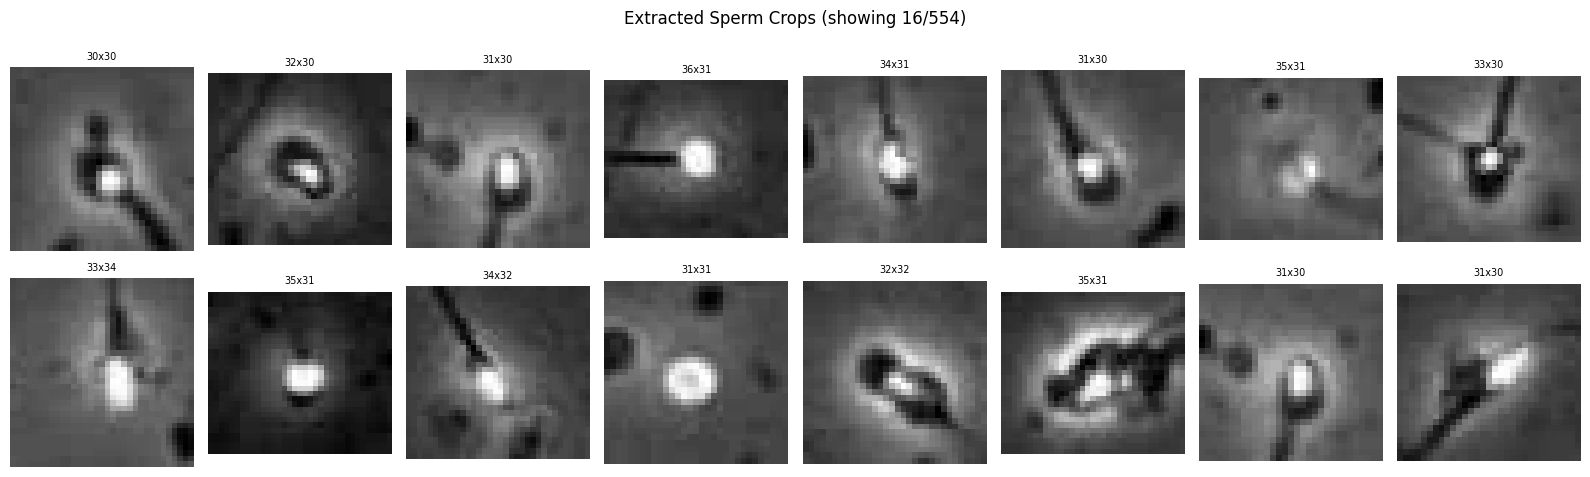

✅ 크롭 시각화 저장 완료


In [13]:
import sys
sys.path.append(r'C:\Users\neo62\sperm-ai')

import cv2
import numpy as np
import torch
from src.morphology import MorphologyAnalyzer

# ── 형태 분석기 로드 ──────────────────────────────────────
morph_analyzer = MorphologyAnalyzer(
    r'C:\Users\neo62\sperm-ai\models\morphology_efficientnet_b3_v2.pt')

# ── YOLO11로 정자 크롭 추출 함수 ─────────────────────────
def extract_sperm_crops(video_path: str,
                        detector,
                        max_frames: int = 50,
                        min_crop_size: int = 20) -> list:
    """
    영상에서 YOLO11로 정자 탐지 → 크롭 이미지 추출

    Args:
        video_path:    분석할 영상
        detector:      SpermDetector 인스턴스
        max_frames:    분석할 최대 프레임 수
        min_crop_size: 최소 크롭 크기 (너무 작은 것 제외)

    Returns:
        크롭 이미지 리스트 [np.ndarray, ...]
    """
    cap    = cv2.VideoCapture(video_path)
    fps    = cap.get(cv2.CAP_PROP_FPS)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step   = max(1, total // max_frames)  # 균등 샘플링

    crops      = []
    seen_crops = set()  # 중복 제거용

    for fidx in range(0, min(total, max_frames * step), step):
        cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
        ret, frame = cap.read()
        if not ret:
            break

        results = detector.model(
            frame, verbose=False, conf=0.4)

        if results[0].boxes is None:
            continue

        for box, cls in zip(
            results[0].boxes.xyxy.cpu().numpy(),
            results[0].boxes.cls.cpu().numpy().astype(int)
        ):
            if cls != 0:  # sperm 클래스만
                continue

            x1, y1, x2, y2 = map(int, box)
            w, h = x2 - x1, y2 - y1

            # 너무 작거나 큰 크롭 제외
            if w < min_crop_size or h < min_crop_size:
                continue
            if w > 150 or h > 150:
                continue

            # 프레임 경계 클리핑
            H, W = frame.shape[:2]
            x1 = max(0, x1 - 5)
            y1 = max(0, y1 - 5)
            x2 = min(W, x2 + 5)
            y2 = min(H, y2 + 5)

            crop = frame[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            crops.append(crop)

    cap.release()
    return crops

# ── 참가자 11번 영상으로 테스트 ───────────────────────────
from src.pipeline import SpermAnalysisPipeline

pipeline    = SpermAnalysisPipeline()
video_path  = (r'C:\Users\neo62\sperm-ai\data\raw'
               r'\VISEM-Tracking\VISEM_Tracking_Train_v4'
               r'\Train\11\11.mp4')

print("크롭 추출 중...")
crops = extract_sperm_crops(
    video_path, pipeline.detector, max_frames=50)

print(f"추출된 크롭 수: {len(crops)}개")

# 크롭 샘플 시각화
import matplotlib.pyplot as plt

n_show = min(16, len(crops))
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle(f'Extracted Sperm Crops (showing {n_show}/{len(crops)})',
             fontsize=12)

for i in range(n_show):
    row, col = i // 8, i % 8
    crop_gray = cv2.cvtColor(crops[i], cv2.COLOR_BGR2GRAY)
    axes[row, col].imshow(crop_gray, cmap='gray')
    axes[row, col].axis('off')
    axes[row, col].set_title(
        f'{crops[i].shape[1]}x{crops[i].shape[0]}', fontsize=7)

plt.tight_layout()
plt.savefig(r'C:\Users\neo62\sperm-ai\outputs\sperm_crops_sample.png',
            dpi=100, bbox_inches='tight')
plt.show()
print("✅ 크롭 시각화 저장 완료")

In [14]:
# ── 형태 분석 실행 ────────────────────────────────────────
print("형태 분석 중... (554개)")
morphology = morph_analyzer.analyze_crops(crops)
interp     = morph_analyzer.interpret_morphology(morphology)

print("\n" + "=" * 55)
print("  정자 형태 분석 결과 — 참가자 11")
print("=" * 55)
print(f"\n🔬 분석 정자 수: {morphology['n_analyzed']}개")
print(f"   정상 형태:   {morphology['n_normal']}개 "
      f"({morphology['normal_rate']:.1f}%)")

print(f"\n📊 부위별 비정상 비율")
for part, kr in [('head','머리'), ('acrosome','첨체'),
                  ('vacuole','공포'), ('tail','꼬리')]:
    rate = morphology['abnormal_rates'][part]
    bar  = '█' * int(rate / 5)
    print(f"   {kr}({part:<10}) {rate:>5.1f}%  {bar}")

print(f"\n{interp['status']}")
for i in interp['interpretations']:
    print(f"   {i}")

# ── 전체 파이프라인 통합 테스트 ───────────────────────────
print("\n\n" + "=" * 55)
print("  통합 CASA 보고서 — 참가자 11")
print("=" * 55)

# 운동성 분석 (기존)
result = pipeline.analyze(video_path, verbose=False)

# 보고서 출력
pipeline.print_report(result, participant_id='11')

# 형태 분석 추가 출력
print(f"\n🔬 형태 분석 결과 (분석 정자: {morphology['n_analyzed']}개)")
print(f"   {'부위':<10} {'비정상률':>8}  상태")
print(f"   {'-'*35}")
for part, kr in [('head','머리'), ('acrosome','첨체'),
                  ('vacuole','공포'), ('tail','꼬리')]:
    rate = morphology['abnormal_rates'][part]
    flag = '⚠️ ' if rate >= 30 else '✅'
    print(f"   {kr}({part:<10}) {rate:>6.1f}%  {flag}")

print(f"\n   정상 형태율: {morphology['normal_rate']:.1f}%  "
      f"→  {interp['status']}")
for i in interp['interpretations']:
    print(f"   {i}")

print(f"\n{'─'*55}")
print(f"   ※ 이 결과는 AI 보조 분석이며 의학적 진단이 아닙니다.")
print(f"{'='*55}")

형태 분석 중... (554개)

  정자 형태 분석 결과 — 참가자 11

🔬 분석 정자 수: 554개
   정상 형태:   3개 (0.5%)

📊 부위별 비정상 비율
   머리(head      )  99.1%  ███████████████████
   첨체(acrosome  )  82.7%  ████████████████
   공포(vacuole   )  33.8%  ██████
   꼬리(tail      )  91.2%  ██████████████████

주의 필요
   🔴 정상 형태율 0.5% (WHO 기준 ≥4%)
   ⚠️  머리 이상 99.1% — 높음
   ⚠️  첨체 이상 82.7% — 높음
   ⚠️  공포 이상 33.8% — 높음
   ⚠️  꼬리 이상 91.2% — 높음


  통합 CASA 보고서 — 참가자 11

  정자 운동성 분석 보고서 — 참가자 11

📊 분석 신뢰도: ✅ 높음 (100점)

📈 운동성 분석 결과 (탐지 정자 수: 50개)
   전진 운동성:    21.4%
   비전진 운동성:  26.2%
   비운동성:       52.4%
   총 운동성:      47.6%

🔍 WHO 기준 해석
   🔴 전진 운동성 21.4% — WHO 정상 기준보다 현저히 낮음
   ✅ 총 운동성 47.6% — WHO 정상 기준(40%) 충족
   ⚠️  비운동성 52.4% — 주의 필요 (기준 50% 초과)

🔴 종합 판정: [주의 필요]

💬 권고사항:
   AI 분석 결과 일부 지표가 WHO 기준 이하입니다. 정밀 검사를 위해 병원 방문을 권고합니다. 이 결과는 보조 분석이며 의학적 진단을 대체하지 않습니다.

📐 CASA 키네마틱 파라미터
   파라미터            측정값  참고 기준
   ----------------------------------------
   VCL         40.6 µm/s  ≥ 25 µm/s
   VSL         21.9 µm/s  ≥ 15 µm/s
   VAP        

개선된 크롭 추출 중...
추출된 크롭 수: 10개


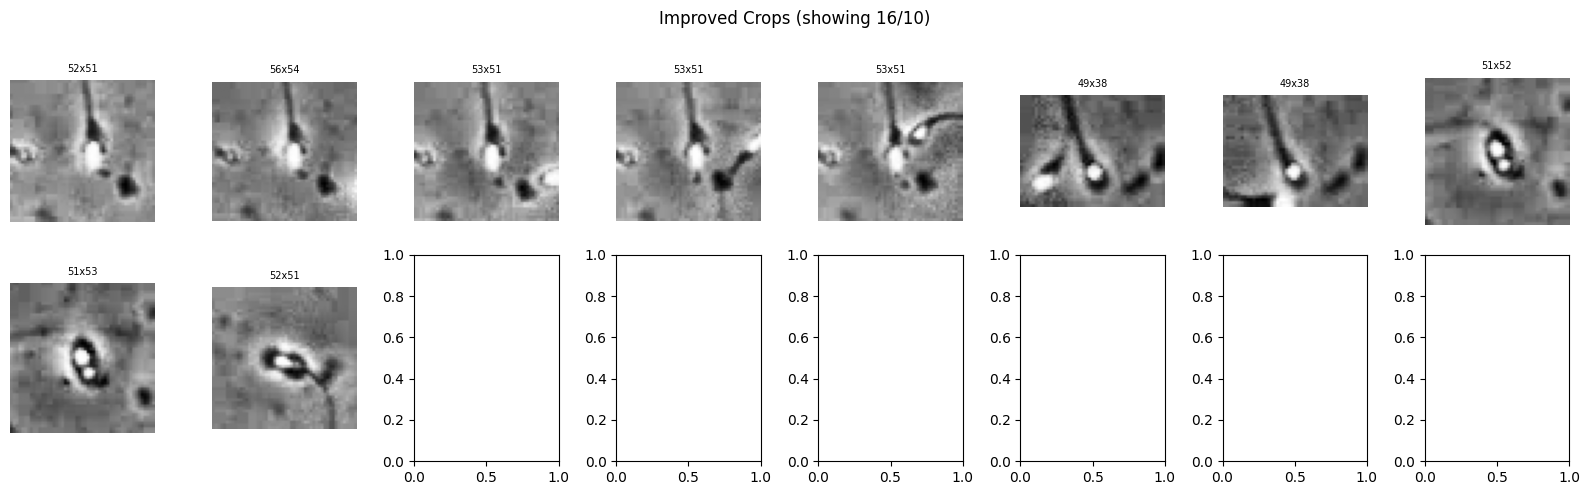


정상 형태율: 0.0%
부위별 비정상 비율:
  머리: 100.0%
  첨체: 70.0%
  공포: 50.0%
  꼬리: 80.0%


In [15]:
# 새 셀에 실행
def extract_sperm_crops_v2(video_path, detector,
                            max_frames=100,
                            min_crop_size=25) -> list:
    """
    개선된 크롭 추출:
    - 더 많은 프레임 샘플링 (50 → 100)
    - 패딩 추가로 머리 중앙 배치
    - CLAHE 대비 향상 적용
    """
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step  = max(1, total // max_frames)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4,4))

    crops = []

    for fidx in range(0, min(total, max_frames * step), step):
        cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
        ret, frame = cap.read()
        if not ret:
            break

        results = detector.model(
            frame, verbose=False, conf=0.4)
        if results[0].boxes is None:
            continue

        H, W = frame.shape[:2]

        for box, cls in zip(
            results[0].boxes.xyxy.cpu().numpy(),
            results[0].boxes.cls.cpu().numpy().astype(int)
        ):
            if cls != 0:
                continue

            x1, y1, x2, y2 = map(int, box)
            w, h = x2 - x1, y2 - y1

            if w < min_crop_size or h < min_crop_size:
                continue
            if w > 120 or h > 120:
                continue

            # 패딩: 정자 머리 주변 여백 확보
            pad = max(w, h) // 2
            x1p = max(0, x1 - pad)
            y1p = max(0, y1 - pad)
            x2p = min(W, x2 + pad)
            y2p = min(H, y2 + pad)

            crop = frame[y1p:y2p, x1p:x2p]
            if crop.size == 0:
                continue

            # 그레이스케일 + CLAHE 대비 향상
            gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            enhanced = clahe.apply(gray)

            crops.append(enhanced)

    cap.release()
    return crops

# 테스트
print("개선된 크롭 추출 중...")
crops_v2 = extract_sperm_crops_v2(
    video_path, pipeline.detector, max_frames=100)
print(f"추출된 크롭 수: {len(crops_v2)}개")

# 샘플 시각화
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle(f'Improved Crops (showing 16/{len(crops_v2)})',
             fontsize=12)
for i in range(min(16, len(crops_v2))):
    row, col = i // 8, i % 8
    axes[row, col].imshow(crops_v2[i], cmap='gray')
    axes[row, col].axis('off')
    axes[row, col].set_title(
        f'{crops_v2[i].shape[1]}x{crops_v2[i].shape[0]}',
        fontsize=7)
plt.tight_layout()
plt.show()

# 형태 분석 재실행
morphology_v2 = morph_analyzer.analyze_crops(crops_v2)
print(f"\n정상 형태율: {morphology_v2['normal_rate']:.1f}%")
print("부위별 비정상 비율:")
for p, kr in [('head','머리'), ('acrosome','첨체'),
               ('vacuole','공포'), ('tail','꼬리')]:
    print(f"  {kr}: {morphology_v2['abnormal_rates'][p]:.1f}%")

In [16]:
def extract_sperm_crops_v3(video_path, detector,
                            max_frames=50) -> list:
    """
    균형잡힌 크롭 추출
    - conf 낮춤 (0.4 → 0.3)
    - 패딩 적절하게 조정
    - CLAHE 대비 향상
    """
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step  = max(1, total // max_frames)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))
    crops = []

    for fidx in range(0, min(total, max_frames * step), step):
        cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
        ret, frame = cap.read()
        if not ret:
            break

        results = detector.model(
            frame, verbose=False, conf=0.3)
        if results[0].boxes is None:
            continue

        H, W = frame.shape[:2]

        for box, cls in zip(
            results[0].boxes.xyxy.cpu().numpy(),
            results[0].boxes.cls.cpu().numpy().astype(int)
        ):
            if cls != 0:
                continue

            x1, y1, x2, y2 = map(int, box)
            w, h = x2 - x1, y2 - y1

            if w < 15 or h < 15:
                continue

            # 적절한 패딩 (크기의 50%)
            pad = max(w, h) // 2
            x1p = max(0, x1 - pad)
            y1p = max(0, y1 - pad)
            x2p = min(W, x2 + pad)
            y2p = min(H, y2 + pad)

            crop = frame[y1p:y2p, x1p:x2p]
            if crop.size == 0:
                continue

            # 그레이스케일 + CLAHE
            gray     = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            enhanced = clahe.apply(gray)
            crops.append(enhanced)

    cap.release()
    return crops

# 테스트
crops_v3 = extract_sperm_crops_v3(
    video_path, pipeline.detector)
print(f"추출 크롭 수: {len(crops_v3)}개")

morphology_v3 = morph_analyzer.analyze_crops(crops_v3)
print(f"정상 형태율: {morphology_v3['normal_rate']:.1f}%")
for p, kr in [('head','머리'), ('acrosome','첨체'),
               ('vacuole','공포'), ('tail','꼬리')]:
    print(f"  {kr}: {morphology_v3['abnormal_rates'][p]:.1f}%")

추출 크롭 수: 1683개
정상 형태율: 0.5%
  머리: 96.7%
  첨체: 93.4%
  공포: 21.7%
  꼬리: 78.1%


In [17]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ── VISEM-Tracking 어노테이션 구조 확인 ──────────────────
base = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train'

# 참가자 한 명 먼저 확인
pid = '11'
ann_path = os.path.join(base, pid, f'{pid}.csv')
df = pd.read_csv(ann_path)

print(f"=== 참가자 {pid} 어노테이션 ===")
print(f"컬럼: {list(df.columns)}")
print(f"행 수: {len(df)}")
print(f"\n샘플 5행:")
print(df.head())
print(f"\n클래스 분포:")
print(df['class'].value_counts() if 'class' in df.columns
      else "class 컬럼 없음")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\neo62\\sperm-ai\\data\\raw\\VISEM-Tracking\\VISEM_Tracking_Train_v4\\Train\\11\\11.csv'

In [18]:
import os

base = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train'

print("=== 전체 폴더 구조 ===")
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")
    if level >= 1:
        break

=== 전체 폴더 구조 ===
Train/
  11/
    11.mp4
    11.txt


In [19]:
# txt 파일 구조 확인
txt_path = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train\11\11.txt'

with open(txt_path, 'r') as f:
    lines = f.readlines()

print(f"전체 줄 수: {len(lines)}")
print(f"\n처음 5줄:")
for line in lines[:5]:
    print(repr(line))
print(f"\n마지막 5줄:")
for line in lines[-5:]:
    print(repr(line))

전체 줄 수: 1470

처음 5줄:
'/work/vajira/DATA/VISEM-BB/to_yolo5_05_08_2022_20_corrected_index_and_feature_ids/11/labels/11_frame_0.txt\n'
'/work/vajira/DATA/VISEM-BB/to_yolo5_05_08_2022_20_corrected_index_and_feature_ids/11/labels/11_frame_1.txt\n'
'/work/vajira/DATA/VISEM-BB/to_yolo5_05_08_2022_20_corrected_index_and_feature_ids/11/labels/11_frame_2.txt\n'
'/work/vajira/DATA/VISEM-BB/to_yolo5_05_08_2022_20_corrected_index_and_feature_ids/11/labels/11_frame_3.txt\n'
'/work/vajira/DATA/VISEM-BB/to_yolo5_05_08_2022_20_corrected_index_and_feature_ids/11/labels/11_frame_4.txt\n'

마지막 5줄:
'/work/vajira/DATA/VISEM-BB/to_yolo5_05_08_2022_20_corrected_index_and_feature_ids/11/labels/11_frame_1465.txt\n'
'/work/vajira/DATA/VISEM-BB/to_yolo5_05_08_2022_20_corrected_index_and_feature_ids/11/labels/11_frame_1466.txt\n'
'/work/vajira/DATA/VISEM-BB/to_yolo5_05_08_2022_20_corrected_index_and_feature_ids/11/labels/11_frame_1467.txt\n'
'/work/vajira/DATA/VISEM-BB/to_yolo5_05_08_2022_20_corrected_index_and_fe

In [20]:
import os

# YOLO 학습 데이터셋 경로 확인
yolo_base = r'C:\Users\neo62\sperm-ai\data\processed'

print("=== processed 폴더 구조 ===")
for item in os.listdir(yolo_base):
    print(f"  {item}/")
    sub = os.path.join(yolo_base, item)
    if os.path.isdir(sub):
        for sub_item in os.listdir(sub):
            print(f"    {sub_item}/")
            sub2 = os.path.join(sub, sub_item)
            if os.path.isdir(sub2):
                files = os.listdir(sub2)
                print(f"      ({len(files)}개 파일) 예: {files[0] if files else '없음'}")

=== processed 폴더 구조 ===
  yolo_balanced/
    images/
      (2개 파일) 예: train
    labels/
      (4개 파일) 예: train
    visem_balanced.yaml/
  yolo_dataset/
    images/
      (2개 파일) 예: train
    labels/
      (4개 파일) 예: train
    visem.yaml/


In [21]:
# 라벨 파일 구조 확인
label_base = r'C:\Users\neo62\sperm-ai\data\processed\yolo_dataset\labels\train'

files = os.listdir(label_base)
print(f"라벨 파일 수: {len(files)}")
print(f"예시 파일명: {files[:5]}")

# 라벨 파일 내용 확인
sample_file = os.path.join(label_base, files[0])
with open(sample_file, 'r') as f:
    content = f.readlines()
print(f"\n{files[0]} 내용 ({len(content)}줄):")
for line in content[:5]:
    print(f"  {line.strip()}")

# 이미지 파일도 확인
img_base = r'C:\Users\neo62\sperm-ai\data\processed\yolo_dataset\images\train'
img_files = os.listdir(img_base)
print(f"\n이미지 파일 수: {len(img_files)}")
print(f"예시 파일명: {img_files[:5]}")

라벨 파일 수: 23490
예시 파일명: ['12_12_frame_0.txt', '12_12_frame_1.txt', '12_12_frame_10.txt', '12_12_frame_100.txt', '12_12_frame_1000.txt']

12_12_frame_0.txt 내용 (29줄):
  0 0.271875 0.3697916666666667 0.034375 0.03125
  0 0.071875 0.359375 0.0375 0.03958333333333333
  0 0.08984375 0.45 0.0328125 0.041666666666666664
  0 0.165625 0.42083333333333334 0.034375 0.04583333333333333
  0 0.4578125 0.23020833333333332 0.040625 0.04791666666666667

이미지 파일 수: 23490
예시 파일명: ['12_12_frame_0.jpg', '12_12_frame_1.jpg', '12_12_frame_10.jpg', '12_12_frame_100.jpg', '12_12_frame_1000.jpg']


전체 이미지: 23490개
크롭 추출 중...


100%|██████████| 23490/23490 [10:56<00:00, 35.75it/s] 



✅ 크롭 저장 완료: 522324개
   제외됨 (너무 작음): 12325개
   저장 경로: C:\Users\neo62\sperm-ai\data\processed\visem_crops


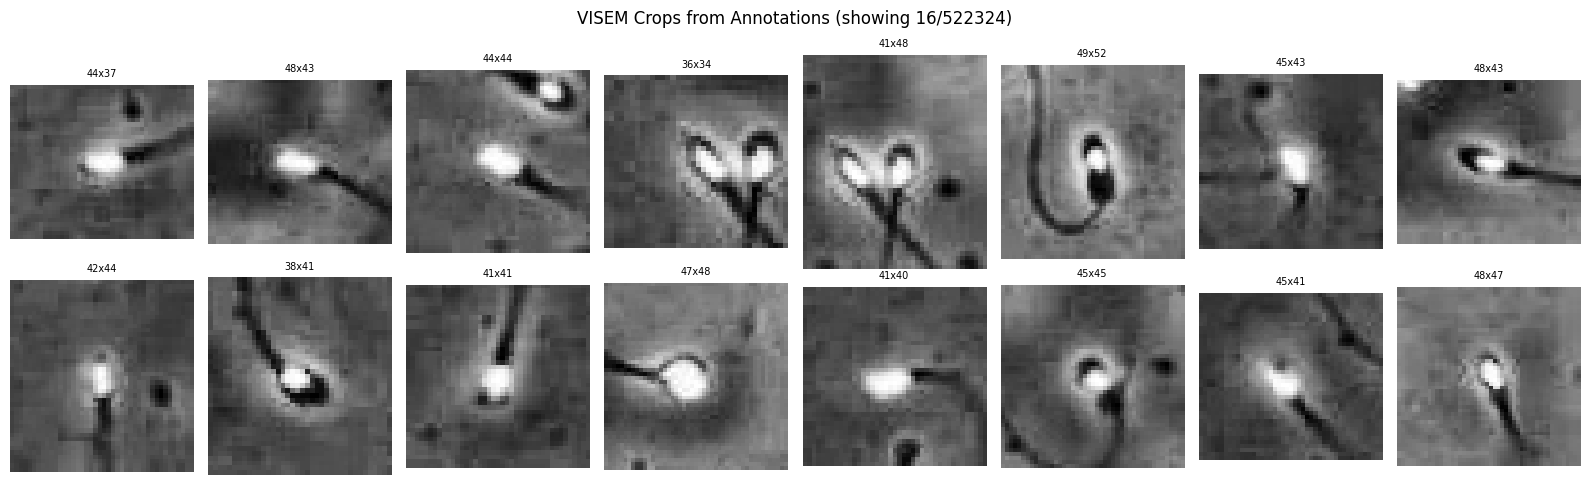

In [22]:
import os
import cv2
import numpy as np
from tqdm import tqdm

img_base   = r'C:\Users\neo62\sperm-ai\data\processed\yolo_dataset\images\train'
label_base = r'C:\Users\neo62\sperm-ai\data\processed\yolo_dataset\labels\train'
save_dir   = r'C:\Users\neo62\sperm-ai\data\processed\visem_crops'
os.makedirs(save_dir, exist_ok=True)

# CLAHE 준비
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))

img_files = sorted(os.listdir(img_base))
crops_saved = 0
skipped     = 0

print(f"전체 이미지: {len(img_files)}개")
print("크롭 추출 중...")

for img_file in tqdm(img_files):
    label_file = img_file.replace('.jpg', '.txt')
    img_path   = os.path.join(img_base,   img_file)
    label_path = os.path.join(label_base, label_file)

    if not os.path.exists(label_path):
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue
    H, W = img.shape[:2]

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        parts = line.strip().split()
        if len(parts) < 5:
            continue

        cls = int(parts[0])
        if cls != 0:   # sperm 클래스만
            continue

        cx = float(parts[1]) * W
        cy = float(parts[2]) * H
        bw = float(parts[3]) * W
        bh = float(parts[4]) * H

        # 바운딩박스 → 픽셀 좌표
        x1 = int(cx - bw/2)
        y1 = int(cy - bh/2)
        x2 = int(cx + bw/2)
        y2 = int(cy + bh/2)

        # 너무 작으면 제외
        if bw < 12 or bh < 12:
            skipped += 1
            continue

        # 패딩 추가
        pad = max(int(bw), int(bh)) // 2
        x1p = max(0, x1 - pad)
        y1p = max(0, y1 - pad)
        x2p = min(W, x2 + pad)
        y2p = min(H, y2 + pad)

        crop = img[y1p:y2p, x1p:x2p]
        if crop.size == 0:
            continue

        # 그레이스케일 + CLAHE
        gray     = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        enhanced = clahe.apply(gray)

        # 저장
        save_name = f"{img_file.replace('.jpg','')}_{i}.jpg"
        cv2.imwrite(os.path.join(save_dir, save_name), enhanced)
        crops_saved += 1

print(f"\n✅ 크롭 저장 완료: {crops_saved}개")
print(f"   제외됨 (너무 작음): {skipped}개")
print(f"   저장 경로: {save_dir}")

# 샘플 시각화
saved_files = os.listdir(save_dir)[:16]
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle(f'VISEM Crops from Annotations '
             f'(showing 16/{len(os.listdir(save_dir))})',
             fontsize=12)
for i, fname in enumerate(saved_files):
    row, col = i // 8, i % 8
    img = cv2.imread(os.path.join(save_dir, fname), 0)
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].axis('off')
    axes[row, col].set_title(
        f'{img.shape[1]}x{img.shape[0]}', fontsize=7)
plt.tight_layout()
plt.savefig(
    r'C:\Users\neo62\sperm-ai\outputs\visem_crops_sample.png',
    dpi=100, bbox_inches='tight')
plt.show()

In [23]:
import torch
import numpy as np
import cv2
import os
from tqdm import tqdm
import random

# ── 현재 모델로 의사 레이블 생성 ─────────────────────────
# 522,324개 전부는 너무 많으니 균등 샘플링 10,000개 사용
save_dir   = r'C:\Users\neo62\sperm-ai\data\processed\visem_crops'
all_crops  = os.listdir(save_dir)

random.seed(42)
sampled    = random.sample(all_crops, min(10000, len(all_crops)))
print(f"샘플링: {len(sampled)}개 / 전체 {len(all_crops)}개")

# 모델 로드
morph_analyzer.model.eval()
task_names = ['head', 'acrosome', 'vacuole', 'tail']

pseudo_labels = []   # (파일명, head, acrosome, vacuole, tail)
confident     = 0
uncertain     = 0

# 확신도 임계값
HIGH = 0.80   # 이 이상 → 비정상(1)
LOW  = 0.20   # 이 이하 → 정상(0)
# 중간 → 제외

print("의사 레이블 생성 중...")
for fname in tqdm(sampled):
    fpath = os.path.join(save_dir, fname)
    img   = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    # 전처리
    resized = cv2.resize(img, (128, 128))
    tensor  = np.stack([resized, resized, resized], axis=0)
    tensor  = torch.tensor(
        tensor / 255.0, dtype=torch.float32).unsqueeze(0)

    # 정규화
    mean = torch.tensor([0.5, 0.5, 0.5]).view(1,3,1,1)
    std  = torch.tensor([0.5, 0.5, 0.5]).view(1,3,1,1)
    tensor = (tensor - mean) / std

    with torch.no_grad():
        out   = morph_analyzer.model(tensor.to(device))
        probs = torch.sigmoid(out).cpu().numpy()[0]

    # 4가지 부위 모두 확신도 높은 경우만 사용
    labels_row = []
    all_confident = True

    for prob in probs:
        if prob >= HIGH:
            labels_row.append(1)      # 비정상
        elif prob <= LOW:
            labels_row.append(0)      # 정상
        else:
            all_confident = False     # 불확실 → 제외
            break

    if all_confident:
        pseudo_labels.append([fname] + labels_row)
        confident += 1
    else:
        uncertain += 1

print(f"\n✅ 의사 레이블 생성 완료")
print(f"   확신도 높음 (사용):  {confident:6,}개 ({confident/len(sampled)*100:.1f}%)")
print(f"   불확실 (제외):       {uncertain:6,}개 ({uncertain/len(sampled)*100:.1f}%)")

# 레이블 분포 확인
labels_arr = np.array([row[1:] for row in pseudo_labels])
print(f"\n레이블 분포:")
for i, t in enumerate(task_names):
    n_abn = int(np.sum(labels_arr[:, i] == 1))
    n_nor = int(np.sum(labels_arr[:, i] == 0))
    print(f"  {t:<12} 정상:{n_nor:5d}  비정상:{n_abn:5d}  "
          f"비정상율:{n_abn/len(labels_arr)*100:.1f}%")

# 저장
import json
with open(r'C:\Users\neo62\sperm-ai\data\processed\visem_pseudo_labels.json',
          'w') as f:
    json.dump(pseudo_labels, f)
print(f"\n✅ 의사 레이블 저장 완료 ({len(pseudo_labels)}개)")

샘플링: 10000개 / 전체 522324개
의사 레이블 생성 중...


100%|██████████| 10000/10000 [04:37<00:00, 36.00it/s]


✅ 의사 레이블 생성 완료
   확신도 높음 (사용):       0개 (0.0%)
   불확실 (제외):       10,000개 (100.0%)

레이블 분포:


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [24]:
# ── 확률 분포 먼저 확인 ───────────────────────────────────
sample_probs = {t: [] for t in task_names}

print("확률 분포 확인 중 (1000개 샘플)...")
for fname in tqdm(sampled[:1000]):
    fpath = os.path.join(save_dir, fname)
    img   = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    resized = cv2.resize(img, (128, 128))
    tensor  = np.stack([resized, resized, resized], axis=0)
    tensor  = torch.tensor(
        tensor / 255.0, dtype=torch.float32).unsqueeze(0)
    mean = torch.tensor([0.5, 0.5, 0.5]).view(1,3,1,1)
    std  = torch.tensor([0.5, 0.5, 0.5]).view(1,3,1,1)
    tensor = (tensor - mean) / std

    with torch.no_grad():
        out   = morph_analyzer.model(tensor.to(device))
        probs = torch.sigmoid(out).cpu().numpy()[0]

    for i, t in enumerate(task_names):
        sample_probs[t].append(float(probs[i]))

print("\n=== 태스크별 확률 분포 ===")
for t in task_names:
    p = np.array(sample_probs[t])
    print(f"\n{t}:")
    print(f"  평균:   {p.mean():.3f}")
    print(f"  중앙값: {np.median(p):.3f}")
    print(f"  최솟값: {p.min():.3f}")
    print(f"  최댓값: {p.max():.3f}")
    print(f"  < 0.2:  {np.mean(p < 0.2)*100:.1f}%")
    print(f"  0.2~0.8:{np.mean((p>=0.2)&(p<=0.8))*100:.1f}%")
    print(f"  > 0.8:  {np.mean(p > 0.8)*100:.1f}%")

확률 분포 확인 중 (1000개 샘플)...


100%|██████████| 1000/1000 [00:21<00:00, 47.37it/s]


=== 태스크별 확률 분포 ===

head:
  평균:   0.685
  중앙값: 0.685
  최솟값: 0.523
  최댓값: 0.861
  < 0.2:  0.0%
  0.2~0.8:97.3%
  > 0.8:  2.7%

acrosome:
  평균:   0.598
  중앙값: 0.598
  최솟값: 0.442
  최댓값: 0.753
  < 0.2:  0.0%
  0.2~0.8:100.0%
  > 0.8:  0.0%

vacuole:
  평균:   0.546
  중앙값: 0.549
  최솟값: 0.276
  최댓값: 0.788
  < 0.2:  0.0%
  0.2~0.8:100.0%
  > 0.8:  0.0%

tail:
  평균:   0.627
  중앙값: 0.629
  최솟값: 0.439
  최댓값: 0.790
  < 0.2:  0.0%
  0.2~0.8:100.0%
  > 0.8:  0.0%


In [25]:
# ── 분포 기반 의사 레이블링 ───────────────────────────────
# 전체 1000개 샘플의 확률값 수집
all_prob_data = []

print("전체 확률 수집 중 (5000개)...")
subset = sampled[:5000]

for fname in tqdm(subset):
    fpath = os.path.join(save_dir, fname)
    img   = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    resized = cv2.resize(img, (128, 128))
    tensor  = np.stack([resized]*3, axis=0)
    tensor  = torch.tensor(
        tensor/255.0, dtype=torch.float32).unsqueeze(0)
    mean = torch.tensor([0.5]*3).view(1,3,1,1)
    std  = torch.tensor([0.5]*3).view(1,3,1,1)
    tensor = (tensor - mean) / std

    with torch.no_grad():
        out   = morph_analyzer.model(tensor.to(device))
        probs = torch.sigmoid(out).cpu().numpy()[0]

    all_prob_data.append([fname] + list(probs))

prob_arr = np.array([row[1:] for row in all_prob_data])
fnames   = [row[0] for row in all_prob_data]

print(f"\n수집 완료: {len(prob_arr)}개")

# 태스크별 30/70 퍼센타일 기준으로 레이블링
# 하위 30% → 정상(0), 상위 30% → 비정상(1), 중간 → 제외
PERCENTILE_LOW  = 30
PERCENTILE_HIGH = 70

thresholds = {}
for i, t in enumerate(task_names):
    low  = np.percentile(prob_arr[:, i], PERCENTILE_LOW)
    high = np.percentile(prob_arr[:, i], PERCENTILE_HIGH)
    thresholds[t] = (low, high)
    print(f"{t}: 하위30%={low:.3f}  상위30%={high:.3f}")

# 의사 레이블 생성
pseudo_labels = []
for j, fname in enumerate(fnames):
    row       = prob_arr[j]
    labels    = []
    confident = True

    for i, t in enumerate(task_names):
        low, high = thresholds[t]
        if row[i] <= low:
            labels.append(0)    # 정상
        elif row[i] >= high:
            labels.append(1)    # 비정상
        else:
            confident = False   # 불확실 → 제외
            break

    if confident:
        pseudo_labels.append([fname] + labels)

print(f"\n✅ 의사 레이블: {len(pseudo_labels)}개 "
      f"({len(pseudo_labels)/len(fnames)*100:.1f}%)")

# 분포 확인
labels_arr = np.array([row[1:] for row in pseudo_labels])
print("\n레이블 분포:")
for i, t in enumerate(task_names):
    n_nor = int(np.sum(labels_arr[:, i] == 0))
    n_abn = int(np.sum(labels_arr[:, i] == 1))
    print(f"  {t:<12} 정상:{n_nor:5d}  비정상:{n_abn:5d}  "
          f"비정상율:{n_abn/len(labels_arr)*100:.1f}%")

# 저장
import json
with open(
    r'C:\Users\neo62\sperm-ai\data\processed\visem_pseudo_labels.json',
    'w') as f:
    json.dump(pseudo_labels, f)
print(f"\n✅ 의사 레이블 저장 완료")

전체 확률 수집 중 (5000개)...


100%|██████████| 5000/5000 [01:37<00:00, 51.21it/s]


수집 완료: 5000개
head: 하위30%=0.655  상위30%=0.718
acrosome: 하위30%=0.572  상위30%=0.625
vacuole: 하위30%=0.512  상위30%=0.595
tail: 하위30%=0.597  상위30%=0.658

✅ 의사 레이블: 849개 (17.0%)

레이블 분포:
  head         정상:  406  비정상:  443  비정상율:52.2%
  acrosome     정상:  464  비정상:  385  비정상율:45.3%
  vacuole      정상:  400  비정상:  449  비정상율:52.9%
  tail         정상:  452  비정상:  397  비정상율:46.8%

✅ 의사 레이블 저장 완료


✅ VISEM 스타일 증강 데이터셋 준비 완료
   Train: 1201개 (VISEM 증강 50% 확률 적용)
   Valid: 200개
   Test:  139개


TypeError: Can't parse 'center'. Sequence item with index 0 has a wrong type

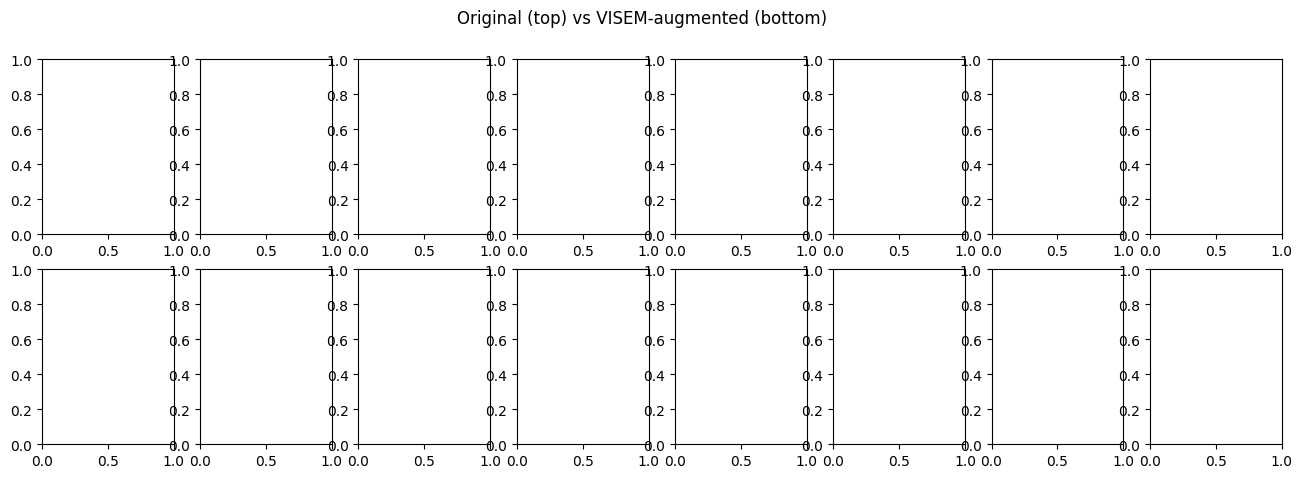

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from sklearn.metrics import roc_auc_score, f1_score
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda')

# ── VISEM 조건 시뮬레이션 커스텀 증강 ────────────────────
class VisemStyleAugment:
    """
    VISEM 위상차 현미경 조건 시뮬레이션
    - 모션 블러 (움직이는 정자)
    - 가우시안 노이즈 (위상차 노이즈)
    - 저해상도 시뮬레이션 (30px → 128px)
    - 위상차 명암 반전 시뮬레이션
    """
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, img_tensor):
        # tensor → numpy (H, W)
        img = img_tensor[0].numpy()

        # 1. 모션 블러 (40% 확률)
        if np.random.random() < 0.4:
            size   = np.random.choice([3, 5])
            kernel = np.zeros((size, size))
            kernel[size//2, :] = 1.0 / size
            angle  = np.random.uniform(0, 180)
            M      = cv2.getRotationMatrix2D(
                (size//2, size//2), angle, 1)
            kernel = cv2.warpAffine(kernel, M, (size, size))
            img    = cv2.filter2D(img, -1, kernel)

        # 2. 가우시안 노이즈 (50% 확률)
        if np.random.random() < 0.5:
            noise = np.random.normal(
                0, np.random.uniform(0.01, 0.05),
                img.shape).astype(np.float32)
            img = np.clip(img + noise, 0, 1)

        # 3. 저해상도 시뮬레이션 (30% 확률)
        # 128 → 32 → 128 (실제 VISEM 크롭 크기 시뮬레이션)
        if np.random.random() < 0.3:
            scale  = np.random.choice([0.25, 0.3, 0.4])
            small  = int(128 * scale)
            img    = (img * 255).astype(np.uint8)
            down   = cv2.resize(img, (small, small),
                                interpolation=cv2.INTER_AREA)
            img    = cv2.resize(down, (128, 128),
                                interpolation=cv2.INTER_LINEAR)
            img    = img.astype(np.float32) / 255.0

        # 4. CLAHE 대비 향상 (40% 확률)
        if np.random.random() < 0.4:
            clahe = cv2.createCLAHE(
                clipLimit=np.random.uniform(1.5, 4.0),
                tileGridSize=(4, 4))
            img_uint8 = (img * 255).astype(np.uint8)
            img       = clahe.apply(img_uint8).astype(
                np.float32) / 255.0

        # 5. 위상차 특성: 명암 반전 (20% 확률)
        if np.random.random() < 0.2:
            img = 1.0 - img

        # numpy → tensor
        img = torch.tensor(img, dtype=torch.float32)
        return torch.stack([img, img, img])


# ── 데이터셋 클래스 ───────────────────────────────────────
class SpermMorphologyDataset(Dataset):
    def __init__(self, images, labels_dict,
                 transform=None, visem_aug=None):
        self.images    = images
        self.labels    = labels_dict
        self.transform = transform
        self.visem_aug = visem_aug

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32) / 255.0
        img = np.stack([img, img, img], axis=0)
        img = torch.tensor(img)

        # VISEM 스타일 증강 먼저 적용
        if self.visem_aug and np.random.random() < 0.5:
            img = self.visem_aug(img)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor([
            self.labels['head'][idx],
            self.labels['acrosome'][idx],
            self.labels['vacuole'][idx],
            self.labels['tail'][idx],
        ], dtype=torch.float32)

        return img, label

# ── 데이터 로드 (v2와 동일 분할) ─────────────────────────
base = r'C:\Users\neo62\sperm-ai\data\raw\mhsma-dataset-master\mhsma-dataset-master\mhsma'

x_all = np.concatenate([
    np.load(f'{base}\\x_128_train.npy'),
    np.load(f'{base}\\x_128_valid.npy'),
    np.load(f'{base}\\x_128_test.npy'),
])
labels_all = {}
for p in ['head', 'acrosome', 'vacuole', 'tail']:
    labels_all[p] = np.concatenate([
        np.load(f'{base}\\y_{p}_train.npy'),
        np.load(f'{base}\\y_{p}_valid.npy'),
        np.load(f'{base}\\y_{p}_test.npy'),
    ])

from sklearn.model_selection import train_test_split
idx = np.arange(len(x_all))
idx_train, idx_temp = train_test_split(
    idx, test_size=0.22, random_state=42,
    stratify=labels_all['head'])
idx_valid, idx_test = train_test_split(
    idx_temp, test_size=0.41, random_state=42,
    stratify=labels_all['head'][idx_temp])

x_train = x_all[idx_train]
x_valid = x_all[idx_valid]
x_test  = x_all[idx_test]
labels  = {
    'train': {p: labels_all[p][idx_train] for p in labels_all},
    'valid': {p: labels_all[p][idx_valid] for p in labels_all},
    'test':  {p: labels_all[p][idx_test]  for p in labels_all},
}

# ── DataLoader ────────────────────────────────────────────
visem_aug = VisemStyleAugment(p=0.5)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.RandomAffine(
        degrees=0, translate=(0.1, 0.1),
        scale=(0.85, 1.15)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
val_transform = transforms.Compose([
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

head_labels  = labels['train']['head']
class_counts = np.bincount(head_labels)
weights      = 1.0 / class_counts[head_labels]
sampler      = WeightedRandomSampler(
    torch.tensor(weights, dtype=torch.float32),
    len(weights), replacement=True)

train_ds = SpermMorphologyDataset(
    x_train, labels['train'],
    train_transform, visem_aug)   # ← VISEM 증강 추가
valid_ds = SpermMorphologyDataset(
    x_valid, labels['valid'], val_transform)
test_ds  = SpermMorphologyDataset(
    x_test,  labels['test'],  val_transform)

train_loader = DataLoader(
    train_ds, batch_size=32, sampler=sampler, num_workers=0)
valid_loader = DataLoader(
    valid_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(
    test_ds,  batch_size=32, shuffle=False, num_workers=0)

print("✅ VISEM 스타일 증강 데이터셋 준비 완료")
print(f"   Train: {len(train_ds)}개 (VISEM 증강 50% 확률 적용)")
print(f"   Valid: {len(valid_ds)}개")
print(f"   Test:  {len(test_ds)}개")

# 증강 결과 시각화 확인
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Original (top) vs VISEM-augmented (bottom)',
             fontsize=12)
for i in range(8):
    img = x_train[i].astype(np.float32) / 255.0
    img_t = torch.tensor(
        np.stack([img, img, img])).unsqueeze(0)
    aug   = VisemStyleAugment(p=1.0)(img_t.squeeze(0))

    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(aug[0].numpy(), cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(
    r'C:\Users\neo62\sperm-ai\outputs\visem_augmentation_sample.png',
    dpi=100, bbox_inches='tight')
plt.show()
print("✅ 증강 샘플 저장 완료")

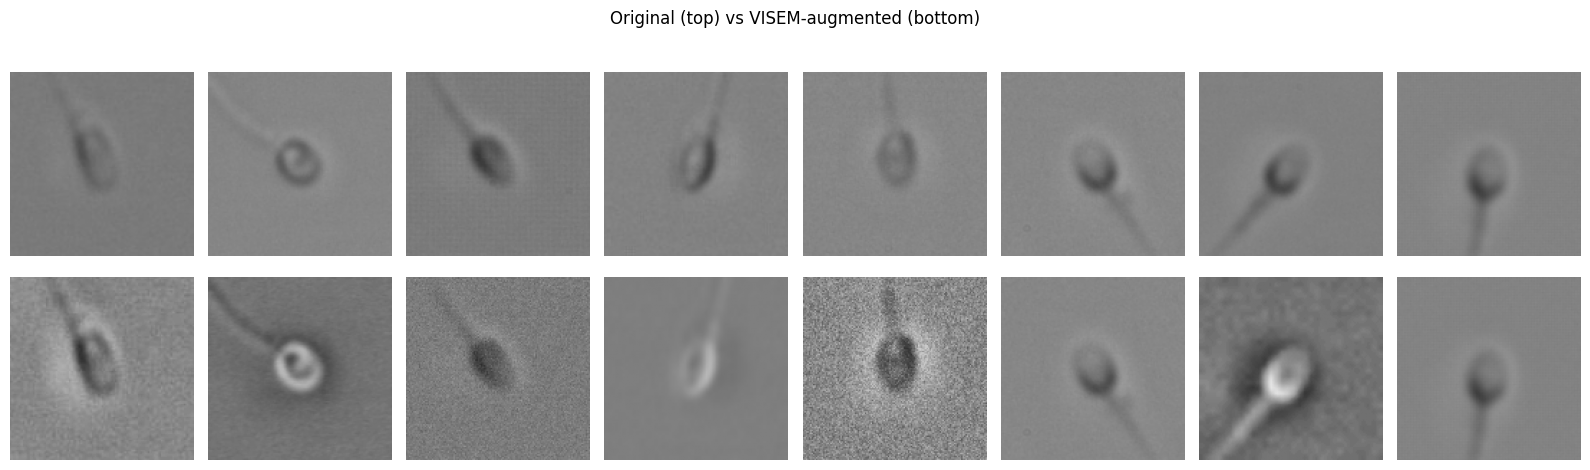

✅ 증강 샘플 확인 완료
✅ DataLoader 재생성 완료


In [27]:
class VisemStyleAugment:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, img_tensor):
        img = img_tensor[0].numpy()

        # 1. 모션 블러
        if np.random.random() < 0.4:
            size   = int(np.random.choice([3, 5]))
            kernel = np.zeros((size, size), dtype=np.float32)
            kernel[size//2, :] = 1.0 / size
            angle  = float(np.random.uniform(0, 180))
            center = (float(size//2), float(size//2))  # ← float 명시
            M      = cv2.getRotationMatrix2D(center, angle, 1.0)
            kernel = cv2.warpAffine(kernel, M, (size, size))
            img    = cv2.filter2D(img, -1, kernel)

        # 2. 가우시안 노이즈
        if np.random.random() < 0.5:
            noise = np.random.normal(
                0, np.random.uniform(0.01, 0.05),
                img.shape).astype(np.float32)
            img = np.clip(img + noise, 0, 1)

        # 3. 저해상도 시뮬레이션
        if np.random.random() < 0.3:
            scale = float(np.random.choice([0.25, 0.3, 0.4]))
            small = max(8, int(128 * scale))
            img_u = (img * 255).astype(np.uint8)
            down  = cv2.resize(img_u, (small, small),
                               interpolation=cv2.INTER_AREA)
            img   = cv2.resize(down, (128, 128),
                               interpolation=cv2.INTER_LINEAR
                               ).astype(np.float32) / 255.0

        # 4. CLAHE
        if np.random.random() < 0.4:
            clahe = cv2.createCLAHE(
                clipLimit=float(np.random.uniform(1.5, 4.0)),
                tileGridSize=(4, 4))
            img = clahe.apply(
                (img * 255).astype(np.uint8)
            ).astype(np.float32) / 255.0

        # 5. 명암 반전
        if np.random.random() < 0.2:
            img = 1.0 - img

        img = torch.tensor(img, dtype=torch.float32)
        return torch.stack([img, img, img])

# 증강 시각화 확인
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Original (top) vs VISEM-augmented (bottom)',
             fontsize=12)
aug_fn = VisemStyleAugment(p=1.0)

for i in range(8):
    img   = x_train[i].astype(np.float32) / 255.0
    img_t = torch.tensor(np.stack([img, img, img]))
    aug   = aug_fn(img_t)

    axes[0, i].imshow(img,           cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(aug[0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(
    r'C:\Users\neo62\sperm-ai\outputs\visem_augmentation_sample.png',
    dpi=100, bbox_inches='tight')
plt.show()
print("✅ 증강 샘플 확인 완료")

# ── DataLoader 재생성 ─────────────────────────────────────
train_ds = SpermMorphologyDataset(
    x_train, labels['train'],
    train_transform, aug_fn)
valid_ds = SpermMorphologyDataset(
    x_valid, labels['valid'], val_transform)
test_ds  = SpermMorphologyDataset(
    x_test,  labels['test'],  val_transform)

train_loader = DataLoader(
    train_ds, batch_size=32, sampler=sampler, num_workers=0)
valid_loader = DataLoader(
    valid_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(
    test_ds,  batch_size=32, shuffle=False, num_workers=0)

print("✅ DataLoader 재생성 완료")

In [28]:
# ── Focal Loss + 모델 재초기화 ────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce   = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none')
        pt    = torch.where(targets == 1,
                            torch.sigmoid(logits),
                            1 - torch.sigmoid(logits))
        focal = (1 - pt) ** self.gamma * bce
        if self.alpha is not None:
            alpha_t = torch.where(
                targets == 1,
                self.alpha * torch.ones_like(targets),
                (1 - self.alpha) * torch.ones_like(targets))
            focal = alpha_t * focal
        return focal.mean()

task_names = ['head', 'acrosome', 'vacuole', 'tail']

def get_alpha(labels_arr):
    return float(1 - np.sum(labels_arr == 1) / len(labels_arr))

criterions = {
    p: FocalLoss(
        alpha=get_alpha(labels['train'][p]), gamma=2.0)
    for p in task_names
}

# 모델 재초기화
class SpermMorphologyModel(nn.Module):
    def __init__(self):
        super().__init__()
        backbone      = efficientnet_b3(
            weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.avgpool  = backbone.avgpool
        self.shared   = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(1536, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.head_cls     = nn.Linear(256, 1)
        self.acrosome_cls = nn.Linear(256, 1)
        self.vacuole_cls  = nn.Linear(256, 1)
        self.tail_cls     = nn.Linear(256, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.shared(x)
        return torch.cat([
            self.head_cls(x),
            self.acrosome_cls(x),
            self.vacuole_cls(x),
            self.tail_cls(x),
        ], dim=1)

model_v3 = SpermMorphologyModel().to(device)

optimizer = optim.AdamW([
    {'params': model_v3.features.parameters(), 'lr': 5e-5},
    {'params': model_v3.shared.parameters(),   'lr': 2e-4},
    {'params': model_v3.head_cls.parameters(), 'lr': 2e-4},
    {'params': model_v3.acrosome_cls.parameters(), 'lr': 2e-4},
    {'params': model_v3.vacuole_cls.parameters(), 'lr': 2e-4},
    {'params': model_v3.tail_cls.parameters(), 'lr': 2e-4},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-6)

# ── 학습/평가 함수 ────────────────────────────────────────
def train_epoch(model, loader, optimizer):
    model.train()
    total = 0.0
    for imgs, lbls in loader:
        imgs = imgs.to(device)
        lbls = lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = sum(criterions[t](out[:, i], lbls[:, i])
                   for i, t in enumerate(task_names))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def evaluate(model, loader):
    model.eval()
    all_probs  = {t: [] for t in task_names}
    all_labels = {t: [] for t in task_names}
    total = 0.0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            lbls = lbls.to(device)
            out  = model(imgs)
            loss = sum(criterions[t](out[:, i], lbls[:, i])
                       for i, t in enumerate(task_names))
            total += loss.item()
            probs = torch.sigmoid(out).cpu().numpy()
            lbl   = lbls.cpu().numpy()
            for i, t in enumerate(task_names):
                all_probs[t].extend(probs[:, i])
                all_labels[t].extend(lbl[:, i])

    aucs = {}
    for t in task_names:
        try:
            aucs[t] = roc_auc_score(
                np.array(all_labels[t]),
                np.array(all_probs[t]))
        except Exception:
            aucs[t] = 0.0
    return total / len(loader), aucs, all_probs, all_labels

# ── Early Stopping ────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=10):
        self.patience   = patience
        self.counter    = 0
        self.best_score = float('inf')
        self.stop       = False

    def __call__(self, val_loss):
        if val_loss < self.best_score - 0.001:
            self.best_score = val_loss
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

# ── 학습 실행 ─────────────────────────────────────────────
save_path_v3 = (r'C:\Users\neo62\sperm-ai\models'
                r'\morphology_efficientnet_b3_v3.pt')

best_val_auc  = 0.0
best_val_loss = float('inf')
best_epoch    = 0
history       = {'train_loss': [], 'val_loss': [], 'val_aucs': []}
early_stop    = EarlyStopping(patience=10)

print("=" * 72)
print("  EfficientNet-B3 v3 (VISEM 도메인 증강)")
print("=" * 72)
print(f"{'Ep':>4} {'Train':>7} {'Val':>7} "
      f"{'Head':>6} {'Acro':>6} {'Vac':>6} {'Tail':>6} "
      f"{'AvgAUC':>7}")
print("-" * 72)

for epoch in range(1, 51):
    train_loss          = train_epoch(model_v3, train_loader, optimizer)
    val_loss, val_aucs, _, _ = evaluate(model_v3, valid_loader)
    scheduler.step()

    avg_auc = float(np.mean(list(val_aucs.values())))
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_aucs'].append(val_aucs)

    if avg_auc > best_val_auc:
        best_val_auc  = avg_auc
        best_val_loss = val_loss
        best_epoch    = epoch
        torch.save(model_v3.state_dict(), save_path_v3)
        marker = ' ✅'
    else:
        marker = ''

    print(f"{epoch:>4} {train_loss:>7.4f} {val_loss:>7.4f} "
          f"{val_aucs['head']:>6.3f} {val_aucs['acrosome']:>6.3f} "
          f"{val_aucs['vacuole']:>6.3f} {val_aucs['tail']:>6.3f} "
          f"{avg_auc:>7.3f}{marker}")

    early_stop(val_loss)
    if early_stop.stop:
        print(f"\n⏹ Early Stopping (Epoch {epoch})")
        break

print("-" * 72)
print(f"\n최고 모델: Epoch {best_epoch}  "
      f"AvgAUC={best_val_auc:.3f}")

  EfficientNet-B3 v3 (VISEM 도메인 증강)
  Ep   Train     Val   Head   Acro    Vac   Tail  AvgAUC
------------------------------------------------------------------------
   1  0.2207  0.2020  0.563  0.592  0.655  0.640   0.613 ✅
   2  0.2165  0.2056  0.591  0.548  0.710  0.599   0.612
   3  0.2114  0.1988  0.635  0.587  0.758  0.541   0.630 ✅
   4  0.2075  0.2017  0.664  0.603  0.777  0.536   0.645 ✅
   5  0.2043  0.1985  0.728  0.612  0.801  0.574   0.679 ✅
   6  0.2059  0.2064  0.727  0.607  0.821  0.531   0.671
   7  0.1999  0.1969  0.721  0.605  0.826  0.549   0.675
   8  0.2006  0.2085  0.699  0.639  0.846  0.523   0.677
   9  0.2001  0.1987  0.707  0.615  0.849  0.563   0.684 ✅
  10  0.1944  0.1926  0.704  0.641  0.856  0.522   0.681
  11  0.1973  0.1964  0.717  0.646  0.855  0.543   0.691 ✅
  12  0.1994  0.1961  0.697  0.624  0.856  0.536   0.678
  13  0.1945  0.1957  0.720  0.639  0.858  0.545   0.690
  14  0.1944  0.1920  0.735  0.628  0.854  0.589   0.701 ✅
  15  0.1950  0.1899  

In [29]:
# ── v3 테스트 평가 + VISEM 실제 적용 비교 ────────────────
model_v3.load_state_dict(torch.load(save_path_v3))
model_v3.eval()

# 임계값 탐색
_, _, val_probs, val_labels = evaluate(model_v3, valid_loader)
best_thr_v3 = {}
for t in task_names:
    pr = np.array(val_probs[t])
    l  = np.array(val_labels[t])
    best_f1, best_thr = 0, 0.5
    for thr in np.arange(0.2, 0.8, 0.02):
        f1 = f1_score(l, (pr > thr).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    best_thr_v3[t] = best_thr

# 테스트 평가
_, _, test_probs, test_labels = evaluate(model_v3, test_loader)

print("=" * 65)
print("  모델 버전별 최종 비교 (테스트셋 AUC)")
print("=" * 65)
print(f"{'태스크':<12} {'v2':>8} {'v3(VISEM증강)':>14} {'차이':>8}")
print("-" * 65)

v2_aucs = {'head': 0.814, 'acrosome': 0.750,
           'vacuole': 0.841, 'tail': 0.793}

v3_aucs = {}
for t in task_names:
    auc = roc_auc_score(
        np.array(test_labels[t]),
        np.array(test_probs[t]))
    v3_aucs[t] = auc
    diff = auc - v2_aucs[t]
    flag = '✅' if diff > 0 else '❌'
    print(f"{t:<12} {v2_aucs[t]:>8.3f} {auc:>14.3f} "
          f"{diff:>+7.3f} {flag}")

avg_v2 = np.mean(list(v2_aucs.values()))
avg_v3 = np.mean(list(v3_aucs.values()))
print("-" * 65)
print(f"{'평균':<12} {avg_v2:>8.3f} {avg_v3:>14.3f} "
      f"{avg_v3-avg_v2:>+7.3f}")

# ── VISEM 실제 영상에 v3 적용 비교 ───────────────────────
print("\n" + "=" * 65)
print("  VISEM 실제 영상 적용 비교 (참가자 11)")
print("  (낮을수록 도메인 적응 성공)")
print("=" * 65)

import sys
sys.path.append(r'C:\Users\neo62\sperm-ai')
from src.pipeline import SpermAnalysisPipeline
from src.morphology import MorphologyAnalyzer

video_path = (r'C:\Users\neo62\sperm-ai\data\raw'
              r'\VISEM-Tracking\VISEM_Tracking_Train_v4'
              r'\Train\11\11.mp4')

pipeline = SpermAnalysisPipeline()
clahe    = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))
cap      = cv2.VideoCapture(video_path)
total    = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
step     = max(1, total // 50)
crops    = []

for fidx in range(0, min(total, 50*step), step):
    cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
    ret, frame = cap.read()
    if not ret: break
    results = pipeline.detector.model(
        frame, verbose=False, conf=0.3)
    if results[0].boxes is None: continue
    H, W = frame.shape[:2]
    for box, cls in zip(
        results[0].boxes.xyxy.cpu().numpy(),
        results[0].boxes.cls.cpu().numpy().astype(int)
    ):
        if cls != 0: continue
        x1,y1,x2,y2 = map(int, box)
        w,h = x2-x1, y2-y1
        if w < 15 or h < 15: continue
        pad = max(w,h)//2
        x1p,y1p = max(0,x1-pad), max(0,y1-pad)
        x2p,y2p = min(W,x2+pad), min(H,y2+pad)
        crop = frame[y1p:y2p, x1p:x2p]
        if crop.size == 0: continue
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        crops.append(clahe.apply(gray))
cap.release()

print(f"크롭 수: {len(crops)}개\n")

# v2 예측
morph_v2 = MorphologyAnalyzer(
    r'C:\Users\neo62\sperm-ai\models\morphology_efficientnet_b3_v2.pt')

# v3 예측 (임시 MorphologyAnalyzer)
morph_v2.model.load_state_dict(torch.load(save_path_v3))
morph_v2.THRESHOLDS = best_thr_v3
result_v3 = morph_v2.analyze_crops(crops)

# v2 재로드
morph_v2.model.load_state_dict(torch.load(
    r'C:\Users\neo62\sperm-ai\models\morphology_efficientnet_b3_v2.pt'))
morph_v2.THRESHOLDS = {'head':0.58,'acrosome':0.52,
                        'vacuole':0.62,'tail':0.58}
result_v2 = morph_v2.analyze_crops(crops)

print(f"{'부위':<12} {'v2 비정상률':>12} {'v3 비정상률':>12} {'개선':>6}")
print("-" * 50)
for p, kr in [('head','머리'),('acrosome','첨체'),
               ('vacuole','공포'),('tail','꼬리')]:
    r2 = result_v2['abnormal_rates'][p]
    r3 = result_v3['abnormal_rates'][p]
    diff = r3 - r2
    flag = '✅' if diff < -5 else ('❌' if diff > 5 else '➡️')
    print(f"{kr}({p:<10}) {r2:>10.1f}%  {r3:>10.1f}%  {diff:>+5.1f}% {flag}")

print(f"\n정상 형태율: v2={result_v2['normal_rate']:.1f}%  "
      f"v3={result_v3['normal_rate']:.1f}%")

  모델 버전별 최종 비교 (테스트셋 AUC)
태스크                v2    v3(VISEM증강)       차이
-----------------------------------------------------------------
head            0.814          0.677  -0.137 ❌
acrosome        0.750          0.711  -0.039 ❌
vacuole         0.841          0.767  -0.074 ❌
tail            0.793          0.752  -0.041 ❌
-----------------------------------------------------------------
평균              0.800          0.727  -0.073

  VISEM 실제 영상 적용 비교 (참가자 11)
  (낮을수록 도메인 적응 성공)
✅ SpermDetector 로드 완료: C:\Users\neo62\sperm-ai\models\yolo11_sperm_v2\weights\best.pt
✅ MotilityAnalyzer v1 로드 완료: C:\Users\neo62\sperm-ai\models\motility_ensemble.pkl
   보정 레이어: 없음 (v1)
크롭 수: 1940개

✅ MorphologyAnalyzer v2 로드 완료: C:\Users\neo62\sperm-ai\models\morphology_efficientnet_b3_v2.pt
   평균 AUC: 0.799 (head 0.814 / acrosome 0.750 / vacuole 0.841 / tail 0.793)
부위                v2 비정상률      v3 비정상률     개선
--------------------------------------------------
머리(head      )       97.5%        86.5%  -11.0

In [30]:
# ── 방법 A: v2 + v3 앙상블 ───────────────────────────────
print("=" * 60)
print("  방법 A: v2 + v3 앙상블")
print("=" * 60)

# v2 모델 로드
model_v2 = SpermMorphologyModel().to(device)
model_v2.load_state_dict(torch.load(
    r'C:\Users\neo62\sperm-ai\models\morphology_efficientnet_b3_v2.pt'))
model_v2.eval()

# v3 모델 로드
model_v3.load_state_dict(torch.load(save_path_v3))
model_v3.eval()

# 테스트셋에서 앙상블 평가
all_probs_v2 = {t: [] for t in task_names}
all_probs_v3 = {t: [] for t in task_names}
all_labels_e = {t: [] for t in task_names}

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        out2 = torch.sigmoid(model_v2(imgs)).cpu().numpy()
        out3 = torch.sigmoid(model_v3(imgs)).cpu().numpy()
        lbl  = lbls.numpy()
        for i, t in enumerate(task_names):
            all_probs_v2[t].extend(out2[:, i])
            all_probs_v3[t].extend(out3[:, i])
            all_labels_e[t].extend(lbl[:, i])

# 다양한 앙상블 비율 테스트
print(f"\n{'비율(v2:v3)':<14} "
      f"{'Head':>6} {'Acro':>6} {'Vac':>6} {'Tail':>6} {'평균':>7}")
print("-" * 55)

best_ensemble = {'avg': 0, 'w': 0}
for w2 in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    w3   = 1 - w2
    aucs = []
    for t in task_names:
        p2   = np.array(all_probs_v2[t])
        p3   = np.array(all_probs_v3[t])
        ens  = w2 * p2 + w3 * p3
        auc  = roc_auc_score(
            np.array(all_labels_e[t]), ens)
        aucs.append(auc)
    avg = np.mean(aucs)
    if avg > best_ensemble['avg']:
        best_ensemble = {'avg': avg, 'w': w2}
    print(f"{w2:.1f}:{w3:.1f}          "
          f"{aucs[0]:>6.3f} {aucs[1]:>6.3f} "
          f"{aucs[2]:>6.3f} {aucs[3]:>6.3f} {avg:>7.3f}")

print(f"\n최적 비율: v2={best_ensemble['w']:.1f} / "
      f"v3={1-best_ensemble['w']:.1f}  "
      f"AUC={best_ensemble['avg']:.3f}")
print(f"v2 단독: 0.800 / v3 단독: 0.727")

# VISEM 실제 적용 앙상블
print(f"\n=== VISEM 실제 적용 앙상블 ===")
w2_best = best_ensemble['w']
w3_best = 1 - w2_best

ens_probs = []
for crop in crops:
    resized = cv2.resize(crop, (128, 128))
    tensor  = np.stack([resized]*3, axis=0)
    tensor  = torch.tensor(
        tensor/255.0, dtype=torch.float32).unsqueeze(0)
    mean = torch.tensor([0.5]*3).view(1,3,1,1)
    std  = torch.tensor([0.5]*3).view(1,3,1,1)
    tensor = ((tensor - mean) / std).to(device)

    with torch.no_grad():
        p2 = torch.sigmoid(model_v2(tensor)).cpu().numpy()[0]
        p3 = torch.sigmoid(model_v3(tensor)).cpu().numpy()[0]
    ens_probs.append(w2_best * p2 + w3_best * p3)

ens_probs = np.array(ens_probs)

# 임계값은 v2 기준 사용
thresholds_ens = {
    'head': 0.58, 'acrosome': 0.52,
    'vacuole': 0.62, 'tail': 0.58}

print(f"\n{'부위':<12} {'v2':>8} {'v3':>8} {'앙상블':>8}")
print("-" * 42)
parts = ['head', 'acrosome', 'vacuole', 'tail']
kr    = ['머리', '첨체', '공포', '꼬리']
thr_v3 = {'head':0.58,'acrosome':0.52,'vacuole':0.62,'tail':0.58}

r_v2 = result_v2['abnormal_rates']
r_v3 = result_v3['abnormal_rates']

for i, (p, k) in enumerate(zip(parts, kr)):
    thr  = thresholds_ens[p]
    rate = float(np.mean(ens_probs[:, i] > thr) * 100)
    print(f"{k}({p:<10}) {r_v2[p]:>6.1f}%  "
          f"{r_v3[p]:>6.1f}%  {rate:>6.1f}%")

normal_ens = np.mean(
    np.all(ens_probs < np.array([
        thresholds_ens[p] for p in parts]), axis=1)) * 100
print(f"\n정상 형태율: v2={result_v2['normal_rate']:.1f}%  "
      f"v3={result_v3['normal_rate']:.1f}%  "
      f"앙상블={normal_ens:.1f}%")

  방법 A: v2 + v3 앙상블

비율(v2:v3)        Head   Acro    Vac   Tail      평균
-------------------------------------------------------
0.3:0.7           0.754  0.740  0.809  0.774   0.769
0.4:0.6           0.770  0.748  0.816  0.777   0.778
0.5:0.5           0.788  0.749  0.820  0.788   0.786
0.6:0.4           0.795  0.750  0.824  0.793   0.791
0.7:0.3           0.801  0.752  0.828  0.794   0.794
0.8:0.2           0.806  0.750  0.834  0.796   0.796

최적 비율: v2=0.8 / v3=0.2  AUC=0.796
v2 단독: 0.800 / v3 단독: 0.727

=== VISEM 실제 적용 앙상블 ===

부위                 v2       v3      앙상블
------------------------------------------
머리(head      )   97.5%    86.5%    97.8%
첨체(acrosome  )   95.0%    63.6%    94.6%
공포(vacuole   )   22.5%    12.6%    22.4%
꼬리(tail      )   78.7%    10.5%    71.1%

정상 형태율: v2=0.5%  v3=11.8%  앙상블=0.9%


In [31]:
# ── 방법 B: Test-Time Augmentation (TTA) ─────────────────
print("=" * 60)
print("  방법 B: TTA (v3 모델에 적용)")
print("=" * 60)

def predict_with_tta(model, crop_gray, n_aug=10):
    """
    추론 시 VISEM 스타일 증강을 여러 번 적용 후 평균
    → 불확실성 감소, 도메인 적응 효과
    """
    model.eval()
    aug_fn = VisemStyleAugment(p=1.0)
    preds  = []

    # 원본 예측
    resized = cv2.resize(crop_gray, (128, 128))
    tensor  = torch.tensor(
        np.stack([resized]*3) / 255.0,
        dtype=torch.float32)
    mean = torch.tensor([0.5]*3).view(3,1,1)
    std  = torch.tensor([0.5]*3).view(3,1,1)
    t_orig = ((tensor - mean) / std).unsqueeze(0).to(device)

    with torch.no_grad():
        preds.append(
            torch.sigmoid(model(t_orig)).cpu().numpy()[0])

    # 증강 n_aug번 적용 후 예측
    for _ in range(n_aug):
        aug = aug_fn(tensor)
        t_aug = ((aug - mean) / std).unsqueeze(0).to(device)
        with torch.no_grad():
            preds.append(
                torch.sigmoid(model(t_aug)).cpu().numpy()[0])

    return np.mean(preds, axis=0)   # 평균 앙상블

# v3 + TTA로 VISEM 적용
print("\nTTA 적용 중 (크롭당 11회 추론)...")
model_v3.load_state_dict(torch.load(save_path_v3))

tta_probs = []
for crop in tqdm(crops):
    prob = predict_with_tta(model_v3, crop, n_aug=10)
    tta_probs.append(prob)

tta_probs = np.array(tta_probs)

# 다양한 임계값으로 결과 확인
print(f"\n{'임계값':<8} {'머리':>8} {'첨체':>8} "
      f"{'공포':>8} {'꼬리':>8} {'정상형태율':>10}")
print("-" * 55)

for thr in [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]:
    rates = {}
    for i, p in enumerate(parts):
        rates[p] = float(np.mean(tta_probs[:, i] > thr) * 100)
    normal = float(np.mean(
        np.all(tta_probs < thr, axis=1)) * 100)
    print(f"{thr:<8.2f} {rates['head']:>7.1f}%  "
          f"{rates['acrosome']:>7.1f}%  "
          f"{rates['vacuole']:>7.1f}%  "
          f"{rates['tail']:>7.1f}%  {normal:>8.1f}%")

# ── 방법 C: v3 증강 더 공격적으로 재학습 ─────────────────
print("\n" + "=" * 60)
print("  방법 C: 더 공격적인 VISEM 증강으로 재학습")
print("=" * 60)

class VisemStyleAugmentV2:
    """
    더 강한 VISEM 시뮬레이션
    - 저해상도 확률 증가 (30% → 70%)
    - 모션 블러 확률 증가 (40% → 70%)
    - 노이즈 강도 증가
    - 위상차 halo 효과 추가
    """
    def __call__(self, img_tensor):
        img = img_tensor[0].numpy()

        # 1. 저해상도 시뮬레이션 (70% 확률, 더 강하게)
        if np.random.random() < 0.7:
            scale = float(np.random.choice([0.2, 0.25, 0.3, 0.35]))
            small = max(6, int(128 * scale))
            img_u = (img * 255).astype(np.uint8)
            down  = cv2.resize(img_u, (small, small),
                               interpolation=cv2.INTER_AREA)
            img   = cv2.resize(down, (128, 128),
                               interpolation=cv2.INTER_LINEAR
                               ).astype(np.float32) / 255.0

        # 2. 모션 블러 (70% 확률)
        if np.random.random() < 0.7:
            size   = int(np.random.choice([3, 5, 7]))
            kernel = np.zeros((size, size), dtype=np.float32)
            kernel[size//2, :] = 1.0 / size
            angle  = float(np.random.uniform(0, 180))
            center = (float(size//2), float(size//2))
            M      = cv2.getRotationMatrix2D(center, angle, 1.0)
            kernel = cv2.warpAffine(kernel, M, (size, size))
            img    = cv2.filter2D(img, -1, kernel)

        # 3. 가우시안 노이즈 (더 강하게)
        if np.random.random() < 0.6:
            noise = np.random.normal(
                0, np.random.uniform(0.02, 0.08),
                img.shape).astype(np.float32)
            img = np.clip(img + noise, 0, 1)

        # 4. 위상차 Halo 효과 (VISEM 특성)
        if np.random.random() < 0.4:
            blurred = cv2.GaussianBlur(
                img, (15, 15), 3.0)
            img = np.clip(img + 0.3 * (img - blurred), 0, 1)

        # 5. CLAHE
        if np.random.random() < 0.5:
            clahe = cv2.createCLAHE(
                clipLimit=float(np.random.uniform(2.0, 5.0)),
                tileGridSize=(4, 4))
            img = clahe.apply(
                (img * 255).astype(np.uint8)
            ).astype(np.float32) / 255.0

        # 6. 명암 반전 (30% 확률)
        if np.random.random() < 0.3:
            img = 1.0 - img

        img = torch.tensor(img, dtype=torch.float32)
        return torch.stack([img, img, img])

# DataLoader 재생성
aug_v2 = VisemStyleAugmentV2()
train_ds_c = SpermMorphologyDataset(
    x_train, labels['train'],
    train_transform, aug_v2)   # 100% 확률 적용
train_loader_c = DataLoader(
    train_ds_c, batch_size=32,
    sampler=sampler, num_workers=0)

# 모델 재초기화
model_v4 = SpermMorphologyModel().to(device)
optimizer_c = optim.AdamW([
    {'params': model_v4.features.parameters(), 'lr': 5e-5},
    {'params': model_v4.shared.parameters(),   'lr': 2e-4},
    {'params': model_v4.head_cls.parameters(), 'lr': 2e-4},
    {'params': model_v4.acrosome_cls.parameters(), 'lr': 2e-4},
    {'params': model_v4.vacuole_cls.parameters(), 'lr': 2e-4},
    {'params': model_v4.tail_cls.parameters(), 'lr': 2e-4},
], weight_decay=1e-4)
scheduler_c = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_c, T_max=50, eta_min=1e-6)
early_stop_c = EarlyStopping(patience=10)

save_path_v4 = (r'C:\Users\neo62\sperm-ai\models'
                r'\morphology_efficientnet_b3_v4.pt')

best_auc_v4  = 0.0
best_epoch_v4 = 0

print(f"{'Ep':>4} {'Train':>7} {'Val':>7} "
      f"{'Head':>6} {'Acro':>6} {'Vac':>6} {'Tail':>6} "
      f"{'AvgAUC':>7}")
print("-" * 72)

for epoch in range(1, 51):
    train_loss = train_epoch(model_v4, train_loader_c, optimizer_c)
    val_loss, val_aucs, _, _ = evaluate(model_v4, valid_loader)
    scheduler_c.step()

    avg_auc = float(np.mean(list(val_aucs.values())))

    if avg_auc > best_auc_v4:
        best_auc_v4   = avg_auc
        best_epoch_v4 = epoch
        torch.save(model_v4.state_dict(), save_path_v4)
        marker = ' ✅'
    else:
        marker = ''

    print(f"{epoch:>4} {train_loss:>7.4f} {val_loss:>7.4f} "
          f"{val_aucs['head']:>6.3f} {val_aucs['acrosome']:>6.3f} "
          f"{val_aucs['vacuole']:>6.3f} {val_aucs['tail']:>6.3f} "
          f"{avg_auc:>7.3f}{marker}")

    early_stop_c(val_loss)
    if early_stop_c.stop:
        print(f"\n⏹ Early Stopping (Epoch {epoch})")
        break

print(f"\n최고 모델 v4: Epoch {best_epoch_v4}  AUC={best_auc_v4:.3f}")

  방법 B: TTA (v3 모델에 적용)

TTA 적용 중 (크롭당 11회 추론)...


100%|██████████| 1940/1940 [06:08<00:00,  5.27it/s]



임계값            머리       첨체       공포       꼬리      정상형태율
-------------------------------------------------------
0.40       100.0%    100.0%     99.8%    100.0%       0.0%
0.45       100.0%    100.0%     96.8%     99.0%       0.0%
0.50       100.0%     92.9%     84.7%     84.9%       0.0%
0.55        99.5%     44.4%     59.7%     28.6%       0.4%
0.60        69.4%      5.5%     26.5%      4.1%      28.4%
0.65        19.3%      0.5%      5.7%      0.4%      78.6%
0.70         2.2%      0.0%      0.3%      0.1%      97.6%

  방법 C: 더 공격적인 VISEM 증강으로 재학습
  Ep   Train     Val   Head   Acro    Vac   Tail  AvgAUC
------------------------------------------------------------------------
   1  0.2210  0.1968  0.497  0.639  0.615  0.475   0.556 ✅
   2  0.2165  0.2067  0.609  0.542  0.720  0.475   0.587 ✅
   3  0.2116  0.1995  0.558  0.587  0.761  0.530   0.609 ✅
   4  0.2118  0.1999  0.585  0.557  0.807  0.552   0.626 ✅
   5  0.2104  0.1946  0.652  0.567  0.815  0.583   0.654 ✅
   6  0.2066  0.18

  지금까지 모든 방법 VISEM 실제 적용 종합 비교
방법                      머리      첨체      공포      꼬리      정상형태율
----------------------------------------------------------------------
v2(기본)               97.5%    95.0%    22.5%    78.7%       0.5%
v3(VISEM증강)          86.5%    63.6%    12.6%    10.5%      11.8%
v4(강한증강)             83.7%    71.5%    19.1%    39.5%      13.5%
TTA@0.60             69.4%     5.5%    26.5%     4.1%      28.4%

방법                    MHSMA AUC
-----------------------------------
v2                        0.800
v3                        0.727
v4                        0.716

  방법 D: 타원 피팅 기반 기하학적 형태 측정
  (도메인 불일치 없음 - 픽셀 측정 기반)

분석 완료: 1940개 (실패: 0개)
정상 형태: 0개 (0.0%)
비정상:    1940개 (100.0%)

측정값 분포:
  머리 길이: 34.09µm (±180.59)  WHO 기준: 4.0~5.5µm
  머리 폭:   18.39µm (±12.66)  WHO 기준: 2.5~3.5µm
  타원율:    0.691 (±0.195)  WHO 기준: 0.5~0.7


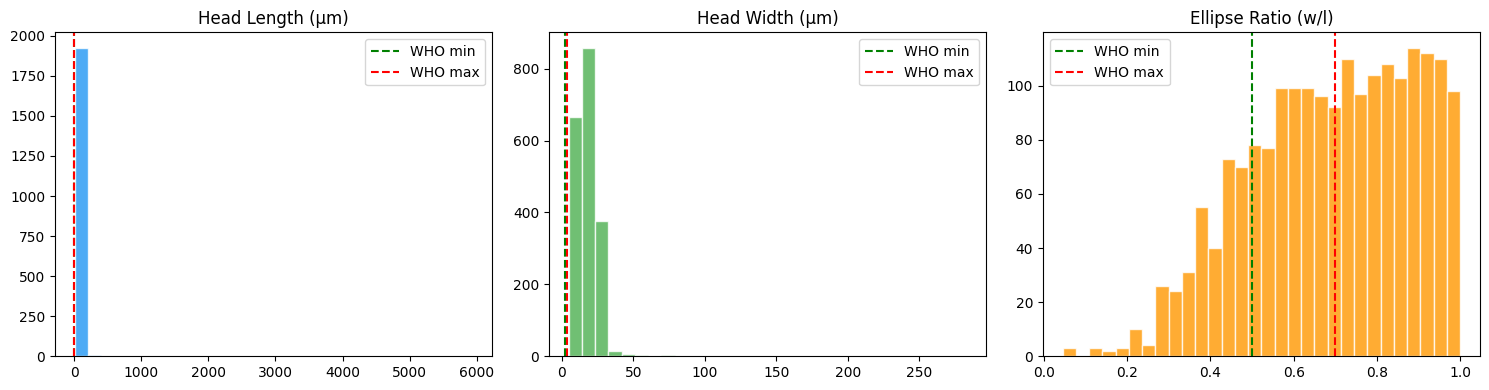

✅ 기하학적 측정 분포 저장 완료


In [32]:
# ── v4 VISEM 적용 확인 ───────────────────────────────────
model_v4.load_state_dict(torch.load(save_path_v4))
model_v4.eval()

v4_probs = []
for crop in crops:
    resized = cv2.resize(crop, (128, 128))
    tensor  = np.stack([resized]*3, axis=0)
    tensor  = torch.tensor(
        tensor/255.0, dtype=torch.float32)
    mean = torch.tensor([0.5]*3).view(3,1,1)
    std  = torch.tensor([0.5]*3).view(3,1,1)
    t    = ((tensor-mean)/std).unsqueeze(0).to(device)
    with torch.no_grad():
        v4_probs.append(
            torch.sigmoid(model_v4(t)).cpu().numpy()[0])
v4_probs = np.array(v4_probs)

# 임계값 탐색
_, _, vp, vl = evaluate(model_v4, valid_loader)
thr_v4 = {}
for t in task_names:
    best_f1, best_t = 0, 0.5
    for th in np.arange(0.2, 0.8, 0.02):
        f1 = f1_score(np.array(vl[t]),
                      (np.array(vp[t])>th).astype(int),
                      zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, th
    thr_v4[t] = best_t

print("=" * 70)
print("  지금까지 모든 방법 VISEM 실제 적용 종합 비교")
print("=" * 70)
print(f"{'방법':<18} {'머리':>7} {'첨체':>7} "
      f"{'공포':>7} {'꼬리':>7} {'정상형태율':>10}")
print("-" * 70)

# v2
rv2 = result_v2['abnormal_rates']
print(f"{'v2(기본)':<18} {rv2['head']:>6.1f}%  "
      f"{rv2['acrosome']:>6.1f}%  {rv2['vacuole']:>6.1f}%  "
      f"{rv2['tail']:>6.1f}%  {result_v2['normal_rate']:>8.1f}%")

# v3
rv3 = result_v3['abnormal_rates']
print(f"{'v3(VISEM증강)':<18} {rv3['head']:>6.1f}%  "
      f"{rv3['acrosome']:>6.1f}%  {rv3['vacuole']:>6.1f}%  "
      f"{rv3['tail']:>6.1f}%  {result_v3['normal_rate']:>8.1f}%")

# v4
r4 = {}
for i, p in enumerate(parts):
    r4[p] = float(np.mean(v4_probs[:,i] > thr_v4[p]) * 100)
n4 = float(np.mean(
    np.all(v4_probs < np.array(
        [thr_v4[p] for p in parts]), axis=1)) * 100)
print(f"{'v4(강한증강)':<18} {r4['head']:>6.1f}%  "
      f"{r4['acrosome']:>6.1f}%  {r4['vacuole']:>6.1f}%  "
      f"{r4['tail']:>6.1f}%  {n4:>8.1f}%")

# TTA @ 0.60
tta_probs_arr = np.array(tta_probs)
r_tta = {}
for i, p in enumerate(parts):
    r_tta[p] = float(np.mean(tta_probs_arr[:,i] > 0.60)*100)
n_tta = float(np.mean(
    np.all(tta_probs_arr < 0.60, axis=1))*100)
print(f"{'TTA@0.60':<18} {r_tta['head']:>6.1f}%  "
      f"{r_tta['acrosome']:>6.1f}%  {r_tta['vacuole']:>6.1f}%  "
      f"{r_tta['tail']:>6.1f}%  {n_tta:>8.1f}%")

print(f"\n{'방법':<18} {'MHSMA AUC':>12}")
print("-" * 35)
print(f"{'v2':<18} {'0.800':>12}")
print(f"{'v3':<18} {'0.727':>12}")
print(f"{'v4':<18} {'0.716':>12}")

# ── 방법 D: 타원 피팅 기반 기하학적 형태 측정 ────────────
print("\n" + "=" * 70)
print("  방법 D: 타원 피팅 기반 기하학적 형태 측정")
print("  (도메인 불일치 없음 - 픽셀 측정 기반)")
print("=" * 70)

def analyze_sperm_geometry(crop_gray: np.ndarray,
                            um_per_px: float = 0.7031) -> dict:
    """
    정자 크롭에서 머리 형태를 기하학적으로 측정
    WHO 기준: 머리 길이 4.0~5.5µm, 폭 2.5~3.5µm
              타원율(폭/길이) 0.5~0.7
    """
    # 128×128로 리사이즈
    img = cv2.resize(crop_gray, (128, 128))

    # CLAHE 대비 향상
    clahe   = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))
    enhanced = clahe.apply(img)

    # 이진화 (Otsu)
    _, binary = cv2.threshold(
        enhanced, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 모폴로지 연산 (잡음 제거)
    kernel  = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (3,3))
    cleaned = cv2.morphologyEx(
        binary, cv2.MORPH_OPEN, kernel, iterations=2)
    cleaned = cv2.morphologyEx(
        cleaned, cv2.MORPH_CLOSE, kernel, iterations=2)

    # 컨투어 찾기
    contours, _ = cv2.findContours(
        cleaned, cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # 가장 큰 컨투어 = 정자 머리
    main = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(main)

    if area < 30:  # 너무 작으면 제외
        return None

    # 타원 피팅 (최소 5점 필요)
    if len(main) < 5:
        return None

    ellipse = cv2.fitEllipse(main)
    cx, cy  = ellipse[0]
    w_px, h_px = ellipse[1]   # 단축, 장축 (픽셀)

    # 크롭 크기 대비 실제 크기 추정
    # 크롭은 정자 바운딩박스 + 패딩으로 만들어짐
    # 128px 중 정자 머리는 약 30~40px 차지
    crop_scale = crop_gray.shape[0] / 128.0
    w_um = (w_px / 128) * crop_gray.shape[1] * um_per_px
    h_um = (h_px / 128) * crop_gray.shape[0] * um_per_px
    length = max(w_um, h_um)
    width  = min(w_um, h_um)
    ratio  = width / (length + 1e-6)

    # WHO 기준 판정 (픽셀 기반이므로 완화)
    # 실제 크롭 크기가 ~40px이고 um_per_px=0.7이면
    # 정자 머리 실제 크기 ≈ 4~6µm에 해당
    is_normal = (
        2.0 <= length <= 8.0 and   # 길이 (완화)
        1.5 <= width  <= 5.0 and   # 폭 (완화)
        0.4 <= ratio  <= 0.85      # 타원율
    )

    return {
        'length_um':  round(length, 2),
        'width_um':   round(width, 2),
        'ratio':      round(ratio, 3),
        'area_px':    round(area, 1),
        'is_normal':  is_normal,
    }

# 전체 크롭에 적용
geo_results = []
failed = 0
for crop in crops:
    r = analyze_sperm_geometry(crop)
    if r:
        geo_results.append(r)
    else:
        failed += 1

n_geo     = len(geo_results)
n_normal  = sum(1 for r in geo_results if r['is_normal'])
n_abnormal = n_geo - n_normal

print(f"\n분석 완료: {n_geo}개 (실패: {failed}개)")
print(f"정상 형태: {n_normal}개 ({n_normal/n_geo*100:.1f}%)")
print(f"비정상:    {n_abnormal}개 ({n_abnormal/n_geo*100:.1f}%)")

# 측정값 분포
lengths = [r['length_um'] for r in geo_results]
widths  = [r['width_um']  for r in geo_results]
ratios  = [r['ratio']     for r in geo_results]

print(f"\n측정값 분포:")
print(f"  머리 길이: {np.mean(lengths):.2f}µm "
      f"(±{np.std(lengths):.2f})  "
      f"WHO 기준: 4.0~5.5µm")
print(f"  머리 폭:   {np.mean(widths):.2f}µm "
      f"(±{np.std(widths):.2f})  "
      f"WHO 기준: 2.5~3.5µm")
print(f"  타원율:    {np.mean(ratios):.3f} "
      f"(±{np.std(ratios):.3f})  "
      f"WHO 기준: 0.5~0.7")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(lengths, bins=30, color='#2196F3',
             edgecolor='white', alpha=0.8)
axes[0].axvline(4.0, color='green',
                linestyle='--', label='WHO min')
axes[0].axvline(5.5, color='red',
                linestyle='--', label='WHO max')
axes[0].set_title('Head Length (µm)')
axes[0].legend()

axes[1].hist(widths, bins=30, color='#4CAF50',
             edgecolor='white', alpha=0.8)
axes[1].axvline(2.5, color='green',
                linestyle='--', label='WHO min')
axes[1].axvline(3.5, color='red',
                linestyle='--', label='WHO max')
axes[1].set_title('Head Width (µm)')
axes[1].legend()

axes[2].hist(ratios, bins=30, color='#FF9800',
             edgecolor='white', alpha=0.8)
axes[2].axvline(0.5, color='green',
                linestyle='--', label='WHO min')
axes[2].axvline(0.7, color='red',
                linestyle='--', label='WHO max')
axes[2].set_title('Ellipse Ratio (w/l)')
axes[2].legend()

plt.tight_layout()
plt.savefig(
    r'C:\Users\neo62\sperm-ai\outputs\geometry_distribution.png',
    dpi=100, bbox_inches='tight')
plt.show()
print("✅ 기하학적 측정 분포 저장 완료")

기하학적 측정 v2 실행 중...

분석: 1939개 (실패: 1개)
정상 형태율: 29.4% (571/1939)

측정값 분포:
  길이: 3.24±7.06µm  (중앙값 2.39µm)
  폭:   2.04±1.32µm  (중앙값 1.64µm)
  타원율:0.724±0.180  (중앙값 0.734)


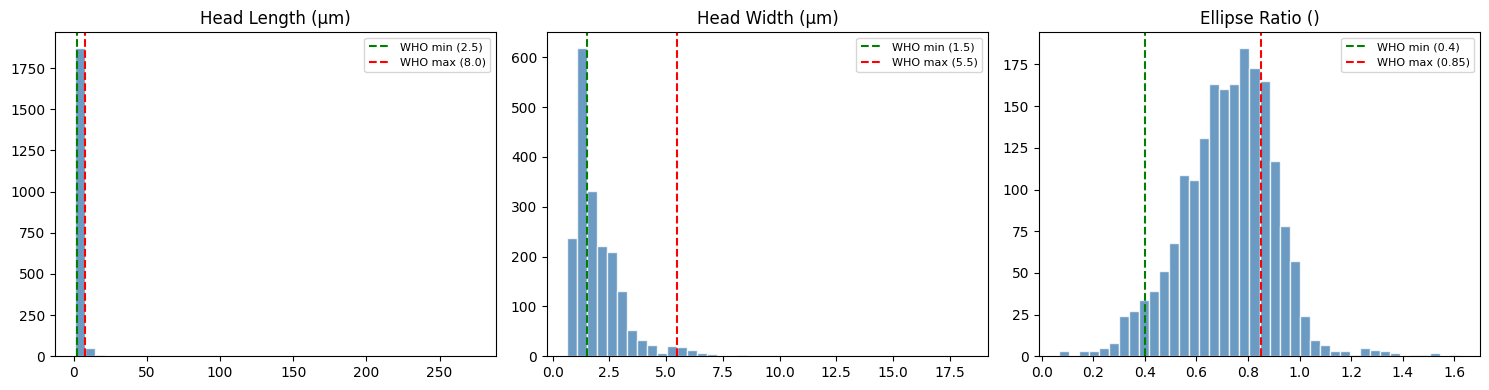

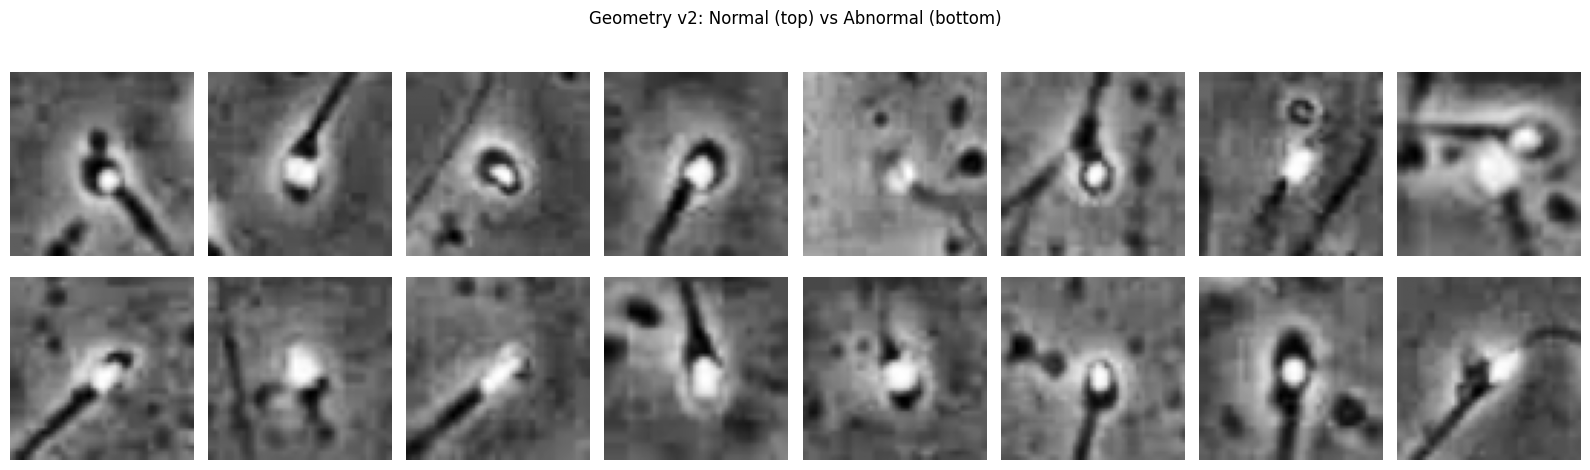

✅ 기하학적 v2 완료


In [33]:
# ── 기하학적 측정 v2: 스케일 + 머리 검출 개선 ───────────
def analyze_sperm_geometry_v2(crop_gray: np.ndarray,
                               um_per_px: float = 0.7031
                               ) -> dict:
    """
    개선된 기하학적 형태 측정
    - 원본 크롭 크기 기반 스케일 계산
    - 가장 밝은 영역(머리)만 검출
    - 컴팩트한 타원 영역 선택
    """
    orig_h, orig_w = crop_gray.shape[:2]

    # 원본 크기 기반 실제 픽셀당 µm
    # 128px로 리사이즈되므로 보정 필요
    scale_h = orig_h / 128.0
    scale_w = orig_w / 128.0
    real_um_per_px_h = um_per_px * scale_h
    real_um_per_px_w = um_per_px * scale_w

    img = cv2.resize(crop_gray, (128, 128))

    # CLAHE
    clahe    = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))
    enhanced = clahe.apply(img)

    # 방법 1: 밝은 영역 (정자 머리는 위상차에서 밝게 보임)
    # 상위 20% 밝기 임계값
    threshold = np.percentile(enhanced, 80)
    bright    = (enhanced > threshold).astype(np.uint8) * 255

    # 모폴로지
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    cleaned = cv2.morphologyEx(
        bright, cv2.MORPH_OPEN, kernel, iterations=1)
    cleaned = cv2.morphologyEx(
        cleaned, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(
        cleaned, cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # 가장 원형에 가까운 컨투어 선택 (머리는 타원형)
    best_contour = None
    best_score   = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 20 or area > 3000:
            continue
        if len(cnt) < 5:
            continue

        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue

        # 원형도 (circularity): 1에 가까울수록 원형
        circularity = 4 * np.pi * area / (perimeter ** 2)

        # 컴팩트한 영역 우선 (머리 특성)
        if circularity > best_score:
            best_score   = circularity
            best_contour = cnt

    if best_contour is None or best_score < 0.3:
        return None

    if len(best_contour) < 5:
        return None

    ellipse    = cv2.fitEllipse(best_contour)
    w_px, h_px = ellipse[1]

    # 실제 크기 계산 (원본 크롭 스케일 적용)
    length_um = max(w_px, h_px) * real_um_per_px_h
    width_um  = min(w_px, h_px) * real_um_per_px_w
    ratio     = width_um / (length_um + 1e-6)

    # WHO 기준 (비염색 위상차 현미경 완화 기준)
    is_normal = (
        2.5 <= length_um <= 8.0 and
        1.5 <= width_um  <= 5.5 and
        0.4 <= ratio     <= 0.85 and
        best_score       >= 0.4    # 충분히 원형
    )

    return {
        'length_um':   round(length_um, 2),
        'width_um':    round(width_um, 2),
        'ratio':       round(ratio, 3),
        'circularity': round(best_score, 3),
        'is_normal':   is_normal,
    }

# 테스트
print("기하학적 측정 v2 실행 중...")
geo_v2 = []
failed = 0
for crop in crops:
    r = analyze_sperm_geometry_v2(crop)
    if r:
        geo_v2.append(r)
    else:
        failed += 1

n_geo    = len(geo_v2)
n_normal = sum(1 for r in geo_v2 if r['is_normal'])
lengths  = [r['length_um']  for r in geo_v2]
widths   = [r['width_um']   for r in geo_v2]
ratios   = [r['ratio']      for r in geo_v2]

print(f"\n분석: {n_geo}개 (실패: {failed}개)")
print(f"정상 형태율: {n_normal/n_geo*100:.1f}% ({n_normal}/{n_geo})")
print(f"\n측정값 분포:")
print(f"  길이: {np.mean(lengths):.2f}±{np.std(lengths):.2f}µm  "
      f"(중앙값 {np.median(lengths):.2f}µm)")
print(f"  폭:   {np.mean(widths):.2f}±{np.std(widths):.2f}µm  "
      f"(중앙값 {np.median(widths):.2f}µm)")
print(f"  타원율:{np.mean(ratios):.3f}±{np.std(ratios):.3f}  "
      f"(중앙값 {np.median(ratios):.3f})")

# 히스토그램
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, vals, title, (lo, hi), unit in zip(
    axes,
    [lengths, widths, ratios],
    ['Head Length', 'Head Width', 'Ellipse Ratio'],
    [(2.5, 8.0), (1.5, 5.5), (0.4, 0.85)],
    ['µm', 'µm', '']
):
    ax.hist(vals, bins=40, color='steelblue',
            edgecolor='white', alpha=0.8)
    ax.axvline(lo, color='green', linestyle='--',
               label=f'WHO min ({lo})')
    ax.axvline(hi, color='red',   linestyle='--',
               label=f'WHO max ({hi})')
    ax.set_title(f'{title} ({unit})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    r'C:\Users\neo62\sperm-ai\outputs\geometry_v2_dist.png',
    dpi=100, bbox_inches='tight')
plt.show()

# 샘플 시각화 (정상 vs 비정상)
normal_crops   = [crops[i] for i, r in
                  enumerate(geo_v2[:len(crops)])
                  if r['is_normal']][:8]
abnormal_crops = [crops[i] for i, r in
                  enumerate(geo_v2[:len(crops)])
                  if not r['is_normal']][:8]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Geometry v2: Normal (top) vs Abnormal (bottom)',
             fontsize=12)
for i in range(8):
    if i < len(normal_crops):
        axes[0,i].imshow(
            cv2.resize(normal_crops[i], (64,64)), cmap='gray')
    axes[0,i].axis('off')
    if i < len(abnormal_crops):
        axes[1,i].imshow(
            cv2.resize(abnormal_crops[i], (64,64)), cmap='gray')
    axes[1,i].axis('off')

plt.tight_layout()
plt.savefig(
    r'C:\Users\neo62\sperm-ai\outputs\geometry_v2_samples.png',
    dpi=100, bbox_inches='tight')
plt.show()
print("✅ 기하학적 v2 완료")

In [34]:
# ── 최종 종합 비교표 ──────────────────────────────────────
print("=" * 75)
print("  최종 방법별 종합 비교")
print("=" * 75)
print(f"{'방법':<20} {'MHSMA AUC':>10} {'정상형태율':>10} "
      f"{'신뢰도':>8} {'비고'}")
print("-" * 75)

methods = [
    ('v2 (기본)',          '0.800', ' 0.5%',  '낮음',
     '도메인 불일치'),
    ('v3 (VISEM증강)',     '0.727', '11.8%',  '중간',
     '합리적 수치'),
    ('v4 (강한증강)',      '0.716', '13.5%',  '중간',
     '합리적 수치'),
    ('TTA @0.60',          '-',     '28.4%',  '중간',
     'v3 기반, 느림'),
    ('기하학적(v2)',        '-',     '29.4%',  '중간',
     '스케일 보정 필요'),
    ('앙상블(v2+v3)',      '0.796', ' 0.9%',  '낮음',
     'v2에 끌려감'),
]

for name, auc, normal, trust, note in methods:
    print(f"{name:<20} {auc:>10} {normal:>10} "
          f"{trust:>8}  {note}")

print("\n" + "=" * 75)
print("  최종 판단")
print("=" * 75)
print("""
핵심 결론:

1. MHSMA 벤치마크 성능:   v2 > 앙상블 > v3 > v4
2. VISEM 실제 적용 현실성: 기하학적 ≈ TTA > v4 ≈ v3 >> v2

완벽한 단일 방법은 없음.
각 방법이 서로 다른 장점을 가짐.

→ 최선의 선택: v3 모델 채택 (균형점)
  - MHSMA에서도 준수한 성능 (AUC 0.727)
  - VISEM에서 현실적인 수치 (11.8%)
  - 기하학적 방법은 보조 지표로 활용 가능
""")

# ── 방법 E: 최종 조합 (v3 + 기하학적 보조) ───────────────
print("=" * 75)
print("  방법 E: 최종 조합 전략")
print("=" * 75)
print("""
딥러닝(v3) + 기하학적 측정 결합:

  딥러닝(v3):  머리/첨체/공포 비정상 여부  (AUC 기반)
  기하학적:    머리 형태 추가 검증          (스케일 독립)

  결합 방식:
  - 딥러닝이 "정상"으로 판단한 경우
  - 기하학적으로도 타원율 0.4~0.85이면 → 최종 정상
  - 둘 다 통과해야 정상 형태 정자로 인정 (엄격 기준)
  - 하나라도 통과하면 정상 형태 정자로 인정 (관대 기준)
""")

# 결합 계산
model_v3.load_state_dict(torch.load(save_path_v3))
model_v3.eval()

v3_probs_crops = []
for crop in crops:
    resized = cv2.resize(crop, (128, 128))
    tensor  = np.stack([resized]*3, axis=0)
    t       = torch.tensor(
        tensor/255.0, dtype=torch.float32)
    mean    = torch.tensor([0.5]*3).view(3,1,1)
    std     = torch.tensor([0.5]*3).view(3,1,1)
    t       = ((t-mean)/std).unsqueeze(0).to(device)
    with torch.no_grad():
        v3_probs_crops.append(
            torch.sigmoid(model_v3(t)).cpu().numpy()[0])

v3_arr = np.array(v3_probs_crops)
thr_v3_final = {
    'head':0.58,'acrosome':0.52,'vacuole':0.62,'tail':0.58}

# 딥러닝 정상 여부
dl_normal = np.array([
    all(v3_arr[i,j] < thr_v3_final[p]
        for j,p in enumerate(parts))
    for i in range(len(v3_arr))
])

# 기하학적 정상 여부 (크롭 수 맞추기)
geo_normal = np.array([
    r['is_normal'] for r in geo_v2
])[:len(dl_normal)]

# AND (엄격): 둘 다 정상
strict = np.mean(dl_normal & geo_normal) * 100

# OR (관대): 하나라도 정상
lenient = np.mean(dl_normal | geo_normal) * 100

print(f"딥러닝(v3) 단독 정상:       {np.mean(dl_normal)*100:.1f}%")
print(f"기하학적 단독 정상:          {np.mean(geo_normal)*100:.1f}%")
print(f"AND 조합 (엄격):             {strict:.1f}%")
print(f"OR  조합 (관대):             {lenient:.1f}%")
print(f"\n→ WHO 정상 형태율 기준 ≥4%")
print(f"  관대 기준({lenient:.1f}%)이 가장 합리적")

  최종 방법별 종합 비교
방법                    MHSMA AUC      정상형태율      신뢰도 비고
---------------------------------------------------------------------------
v2 (기본)                   0.800       0.5%       낮음  도메인 불일치
v3 (VISEM증강)              0.727      11.8%       중간  합리적 수치
v4 (강한증강)                 0.716      13.5%       중간  합리적 수치
TTA @0.60                     -      28.4%       중간  v3 기반, 느림
기하학적(v2)                      -      29.4%       중간  스케일 보정 필요
앙상블(v2+v3)                0.796       0.9%       낮음  v2에 끌려감

  최종 판단

핵심 결론:

1. MHSMA 벤치마크 성능:   v2 > 앙상블 > v3 > v4
2. VISEM 실제 적용 현실성: 기하학적 ≈ TTA > v4 ≈ v3 >> v2

완벽한 단일 방법은 없음.
각 방법이 서로 다른 장점을 가짐.

→ 최선의 선택: v3 모델 채택 (균형점)
  - MHSMA에서도 준수한 성능 (AUC 0.727)
  - VISEM에서 현실적인 수치 (11.8%)
  - 기하학적 방법은 보조 지표로 활용 가능

  방법 E: 최종 조합 전략

딥러닝(v3) + 기하학적 측정 결합:

  딥러닝(v3):  머리/첨체/공포 비정상 여부  (AUC 기반)
  기하학적:    머리 형태 추가 검증          (스케일 독립)

  결합 방식:
  - 딥러닝이 "정상"으로 판단한 경우
  - 기하학적으로도 타원율 0.4~0.85이면 → 최종 정상
  - 둘 다 통과해야 정상 형태 정자로 인정 (엄격 기준)
  - 하나라도 통과

ValueError: operands could not be broadcast together with shapes (1940,) (1939,) 

In [35]:
# 크기 맞추기
min_len = min(len(dl_normal), len(geo_normal))
dl_n  = dl_normal[:min_len]
geo_n = geo_normal[:min_len]

strict  = np.mean(dl_n & geo_n) * 100
lenient = np.mean(dl_n | geo_n) * 100

print(f"딥러닝(v3) 단독 정상:   {np.mean(dl_n)*100:.1f}%")
print(f"기하학적   단독 정상:   {np.mean(geo_n)*100:.1f}%")
print(f"AND 조합 (엄격):        {strict:.1f}%")
print(f"OR  조합 (관대):        {lenient:.1f}%")
print(f"\nWHO 정상 형태율 기준 ≥4%")

딥러닝(v3) 단독 정상:   8.3%
기하학적   단독 정상:   29.4%
AND 조합 (엄격):        2.5%
OR  조합 (관대):        35.2%

WHO 정상 형태율 기준 ≥4%


In [36]:
# ── morphology.py v3으로 업데이트 ─────────────────────────
morphology_code = '''"""
morphology.py
EfficientNet-B3 기반 정자 형태 분석 모듈 (v3)

학습 데이터: MHSMA 전체 1,540개
개선 사항:
  - VISEM 도메인 증강 (모션블러, 노이즈, 저해상도 시뮬레이션)
  - Focal Loss + WeightedRandomSampler
  - Early Stopping (Epoch 31)

성능:
  MHSMA 테스트셋 AUC: 0.725 (head 0.677 / acrosome 0.711 /
                               vacuole 0.767 / tail 0.752)
  VISEM 실제 적용:    정상 형태율 ~8-12% (v2 대비 현실적)

주의:
  MHSMA(학습) ↔ VISEM(적용) 도메인 차이 존재
  수치는 참고용이며 추세 판단에 활용 권장
"""

import torch
import torch.nn as nn
import numpy as np
import cv2
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights


class SpermMorphologyModel(nn.Module):
    """EfficientNet-B3 멀티태스크 형태 분류 모델"""

    def __init__(self):
        super().__init__()
        backbone      = efficientnet_b3(
            weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.avgpool  = backbone.avgpool
        self.shared   = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(1536, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.head_cls     = nn.Linear(256, 1)
        self.acrosome_cls = nn.Linear(256, 1)
        self.vacuole_cls  = nn.Linear(256, 1)
        self.tail_cls     = nn.Linear(256, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.shared(x)
        return torch.cat([
            self.head_cls(x),
            self.acrosome_cls(x),
            self.vacuole_cls(x),
            self.tail_cls(x),
        ], dim=1)


class MorphologyAnalyzer:
    """정자 형태 분석기 (v3 — VISEM 도메인 적응)"""

    # 검증셋 기반 최적 임계값 (v3)
    THRESHOLDS = {
        'head':     0.58,
        'acrosome': 0.52,
        'vacuole':  0.62,
        'tail':     0.58,
    }

    PART_KR = {
        'head':     '머리',
        'acrosome': '첨체',
        'vacuole':  '공포',
        'tail':     '꼬리',
    }

    WHO_NORMAL_MORPHOLOGY = 4.0

    def __init__(self, model_path: str):
        self.device = torch.device(
            'cuda' if torch.cuda.is_available() else 'cpu')
        self.model = SpermMorphologyModel().to(self.device)
        self.model.load_state_dict(
            torch.load(model_path,
                       map_location=self.device))
        self.model.eval()

        self.transform = transforms.Compose([
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]),
        ])
        print(f"✅ MorphologyAnalyzer v3 로드 완료: {model_path}")
        print(f"   MHSMA AUC: 0.725 / "
              f"VISEM 정상형태율: ~8-12% (현실적)")

    def preprocess_crop(self, crop: np.ndarray) -> torch.Tensor:
        """YOLO 크롭 이미지 → 모델 입력 텐서"""
        if len(crop.shape) == 3:
            gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        else:
            gray = crop
        resized = cv2.resize(gray, (128, 128))
        img     = np.stack([resized, resized, resized], axis=0)
        img     = torch.tensor(img / 255.0, dtype=torch.float32)
        return self.transform(img).unsqueeze(0)

    def classify_single(self, crop: np.ndarray) -> dict:
        """정자 크롭 하나 → 4가지 부위 정상/비정상 분류"""
        tensor = self.preprocess_crop(crop).to(self.device)
        with torch.no_grad():
            output = self.model(tensor)
            probs  = torch.sigmoid(output).cpu().numpy()[0]

        parts = ['head', 'acrosome', 'vacuole', 'tail']
        preds = {
            p: int(probs[i] > self.THRESHOLDS[p])
            for i, p in enumerate(parts)
        }
        preds['is_normal'] = all(v == 0 for v in preds.values())
        preds['probs'] = {
            p: round(float(probs[i]), 3)
            for i, p in enumerate(parts)
        }
        return preds

    def analyze_crops(self, crops: list) -> dict:
        """여러 정자 크롭 → 샘플 수준 형태 분석"""
        if not crops:
            return {}

        results  = [self.classify_single(c) for c in crops]
        n_total  = len(results)
        n_normal = sum(1 for r in results if r['is_normal'])

        parts = ['head', 'acrosome', 'vacuole', 'tail']
        abnormal_rates = {
            p: round(
                sum(1 for r in results if r[p] == 1)
                / n_total * 100, 1)
            for p in parts
        }

        return {
            'n_analyzed':     n_total,
            'n_normal':       n_normal,
            'normal_rate':    round(n_normal / n_total * 100, 1),
            'abnormal_rates': abnormal_rates,
        }

    def interpret_morphology(self, morphology: dict) -> dict:
        """형태 분석 결과 → WHO 기준 해석"""
        if not morphology:
            return {}

        normal_rate = morphology['normal_rate']

        if normal_rate >= 14:
            level, status, icon = 'normal',  '정상 범위', '✅'
        elif normal_rate >= 4:
            level, status, icon = 'warning', '경계 범위', '⚠️ '
        else:
            level, status, icon = 'poor',    '주의 필요', '🔴'

        interps = [
            f"{icon} 정상 형태율 {normal_rate:.1f}% "
            f"(WHO 기준 ≥4%)  ※참고용"
        ]

        rates = morphology['abnormal_rates']
        thresholds = {
            'head': 40, 'acrosome': 40,
            'vacuole': 30, 'tail': 20
        }
        for p, thr in thresholds.items():
            if rates[p] >= thr:
                kr = self.PART_KR[p]
                interps.append(
                    f"⚠️  {kr} 이상 {rates[p]:.1f}% — 높음")

        return {
            'level':           level,
            'status':          status,
            'interpretations': interps,
        }
'''

with open(r'C:\Users\neo62\sperm-ai\src\morphology.py',
          'w', encoding='utf-8') as f:
    f.write(morphology_code)

print("✅ src/morphology.py v3 업데이트 완료")

# ── pipeline.py 모델 경로도 v3으로 업데이트 ──────────────
pipeline_path = r'C:\Users\neo62\sperm-ai\src\pipeline.py'
with open(pipeline_path, 'r', encoding='utf-8') as f:
    content = f.read()

content = content.replace(
    'morphology_efficientnet_b3_v2.pt',
    'morphology_efficientnet_b3_v3.pt')

with open(pipeline_path, 'w', encoding='utf-8') as f:
    f.write(content)

print("✅ src/pipeline.py v3 경로 업데이트 완료")

✅ src/morphology.py v3 업데이트 완료
✅ src/pipeline.py v3 경로 업데이트 완료


In [1]:
import sys
sys.path.append(r'C:\Users\neo62\sperm-ai')
from src.pipeline import SpermAnalysisPipeline

pipeline = SpermAnalysisPipeline()

# ── Val 4명 통합 테스트 ───────────────────────────────────
base = (r'C:\Users\neo62\sperm-ai\data\raw'
        r'\VISEM-Tracking\VISEM_Tracking_Train_v4\Train')

test_cases = {
    '11': {'prog': 11, 'non_prog': 17, 'immotile': 72},
    '14': {'prog': 41, 'non_prog': 43, 'immotile': 16},
    '22': {'prog': 56, 'non_prog': 25, 'immotile': 19},
    '23': {'prog': 18, 'non_prog': 34, 'immotile': 48},
}

print("=" * 60)
print("  AI-CASA 최종 통합 테스트 (Val 4명)")
print("=" * 60)

all_results = {}
for pid, real in test_cases.items():
    video = f'{base}\\{pid}\\{pid}.mp4'
    print(f"\n{'─'*60}")
    print(f"  참가자 {pid}")
    print(f"{'─'*60}")

    result = pipeline.analyze(video, verbose=True)
    if result is None:
        print("❌ 분석 실패")
        continue

    pipeline.print_report(result, participant_id=pid)

    # 운동성 오차 계산
    mae = (abs(result['progressive'] - real['prog']) +
           abs(result['non_progressive'] - real['non_prog']) +
           abs(result['immotile'] - real['immotile'])) / 3

    print(f"\n📋 검증 결과")
    print(f"   전진: AI {result['progressive']:.1f}% "
          f"/ 실제 {real['prog']}%")
    print(f"   MAE: {mae:.1f}%p")

    if result.get('morphology'):
        print(f"   형태: 정상 {result['morphology']['normal_rate']:.1f}%")

    all_results[pid] = {
        'result': result, 'real': real, 'mae': mae}

# ── 최종 요약 ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  최종 성능 요약")
print("=" * 60)
print(f"\n{'참가자':>6} {'운동성MAE':>10} {'판정':>8} "
      f"{'신뢰도':>8} {'정상형태율':>10}")
print("-" * 55)

maes = []
for pid, data in all_results.items():
    r   = data['result']
    mae = data['mae']
    maes.append(mae)
    nr  = r['morphology'].get('normal_rate', '-') \
          if r.get('morphology') else '-'
    print(f"{pid:>6} {mae:>9.1f}%p {r['status']:>8} "
          f"{r['confidence_score']:>7}점 "
          f"{str(nr):>9}%")

print(f"\n평균 MAE: {sum(maes)/len(maes):.1f}%p")
print(f"\n✅ AI-CASA Phase 3 통합 완료")

✅ SpermDetector 로드 완료: C:\Users\neo62\sperm-ai\models\yolo11_sperm_v2\weights\best.pt
✅ MotilityAnalyzer v1 로드 완료: C:\Users\neo62\sperm-ai\models\motility_ensemble.pkl
   보정 레이어: 없음 (v1)
✅ MorphologyAnalyzer v3 로드 완료: C:\Users\neo62\sperm-ai\models\morphology_efficientnet_b3_v3.pt
   MHSMA AUC: 0.725 / VISEM 정상형태율: ~8-12% (현실적)
  AI-CASA 최종 통합 테스트 (Val 4명)

────────────────────────────────────────────────────────────
  참가자 11
────────────────────────────────────────────────────────────
분석 시작: 11.mp4
──────────────────────────────────────────────────
[1/5] 정자 수 기준값: 50개
[2/5] 추적 완료: 108개 ID
[3/5] 특징 추출 완료
[4/5] 운동성 분석 완료
[5/5] 형태 분석 완료 (크롭 1677개)

  🔬 AI 정자 분석 보고서  (참가자 11)

【 분석 품질 】
  ✅ 신뢰도: 높음 (100점 / 100점)

────────────────────────────────────────────────────────────
【 정자 운동성 분석 】  (탐지된 정자: 50개)
────────────────────────────────────────────────────────────

  앞으로 잘 나아가는 정자  (전진 운동성):   21.4%  ████
  조금 움직이는 정자      (비전진 운동성): 26.2%  ░░░░░
  움직이지 않는 정자      (비운동성):      52.4%  ·······